# **Thông tin nhóm:**

**NHÓM 13**
* **Sinh viên 1:** 030239230284 - Nguyễn Thái Thanh Vân

* **Sinh viên 2:** 030239230279 - Nguyễn Thị Phương Uyên

* **Sinh viên 3:** 030239230204 - Nguyễn Thị Diễm Quỳnh

* **Sinh viên 4:** 030239230131 - Trần Phan Ly Na

# **BẢNG PHÂN CÔNG NHIỆM VỤ**

In [53]:
import pandas as pd

# Tạo dữ liệu cho nhóm
data = {
    'STT': [1, 2, 3, 4],
    'Họ và Tên': ['Nguyễn Thái Thanh Vân (Nhóm trưởng)', 'Nguyễn Thị Phương Uyên', ' Nguyễn Thị Diễm Quỳnh', 'Trần Phan Ly Na'],
    'MSSV': ['030239230284', '030239230279', '030239230204', '030239230131'],
    'Nhiệm vụ phân công': [
        'Phần 1 (Huấn luyện & Đánh giá: Cụm mô hình tuyến tính & phi tuyến tính, So sánh, Nhận xét và kết luận, kiểm tra bổ sung phần 2 và tổng kết hoàn thiện)',
        'Phần 1 (Tiền xử lý dữ liệu và EDA, Kiểm định dữ liệu cho hồi quy tuyến tính)',
        'Phần 2 (Thu thập và tiền xử lý dữ liệu chứng khoán VN30, Ý nghĩa tài chính của trọng số cổ phiếu)',
        'Phần 2 (Xây dựng thuật toán PCA (From scratch bằng Numpy), Phân tích Tương quan & Ý nghĩa tài chính)'

    ],
    'Mức độ đóng góp': ['30%', '25%', '20%', '25%']
}

# Tạo DataFrame và in ra bảng
df_nhom = pd.DataFrame(data)

# Đặt cột STT làm index cho đẹp
df_nhom.set_index('STT', inplace=True)

# Hiển thị bảng
df_nhom

,Họ và Tên,MSSV,Nhiệm vụ phân công,Mức độ đóng góp
STT,,,,
1,Nguyễn Thái Thanh Vân (Nhóm trưởng),030239230284,Phần 1 (Huấn luyện & Đánh giá: Cụm mô hình tuy...,30%
2,Nguyễn Thị Phương Uyên,030239230279,"Phần 1 (Tiền xử lý dữ liệu và EDA, Kiểm định d...",25%
3,Nguyễn Thị Diễm Quỳnh,030239230204,Phần 2 (Thu thập và tiền xử lý dữ liệu chứng k...,20%
4,Trần Phan Ly Na,030239230131,Phần 2 (Xây dựng thuật toán PCA (From scratch ...,25%


# **PHẦN 1 – Phân tích dữ liệu rủi ro tín dụng (Lending Club) bằng hồi quy và học máy**


---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.ticker as ticker

## **1.1 Tiền xử lý dữ liệu**

In [ ]:
# Đọc file dữ liệu
file_path = '/content/data.csv'
cols_to_ignore = ['id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code']

# Hàm tối ưu kiểu dữ liệu cho từng chunk (để không tốn RAM)
def optimize_dtypes(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = pd.to_numeric(df[col], downcast='float')
        elif df[col].dtype == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

# Đọc file theo từng cụm
chunk_size = 50000
chunks = []

print("Đang đọc và tối ưu hóa dữ liệu...")

for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
    # Loại bỏ ngay các cột không cần thiết để giải phóng RAM
    chunk = chunk.drop(columns=[c for c in cols_to_ignore if c in chunk.columns])

    # Tối ưu kiểu dữ liệ
    chunk = optimize_dtypes(chunk)

    chunks.append(chunk)

# Gộp các mảnh lại thành dataframe duy nhất
df = pd.concat(chunks, axis=0)

print(f"Thành công! Dữ liệu hiện tại có: {df.shape}")
df.info(memory_usage='deep')

Đang đọc và tối ưu hóa dữ liệu...
Thành công! Dữ liệu hiện tại có: (1397, 144)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Columns: 144 entries, loan_amnt to settlement_term
dtypes: float32(103), float64(10), object(31)
memory usage: 2.6 MB


In [ ]:
# Xử lý Missing value
# Tính tỷ lệ missing để quyết định xóa hay điền
missing_pct = df.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 50].index # Xóa các cột trống trên 50%
df.drop(columns=cols_to_drop, inplace=True)
print(f"Đã xóa {len(cols_to_drop)} cột có tỷ lệ trống > 50%.")

# Fill numerical bằng median và categorical bằng mode (Vectorized)
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Tổng số giá trị thiếu còn lại: {df.isnull().sum().sum()}")

Đã xóa 41 cột có tỷ lệ trống > 50%.
Tổng số giá trị thiếu còn lại: 0


In [ ]:
# Xử lý Null values
# Loại bỏ các cột có > 50% giá trị thiếu (không có giá trị thống kê)
limit = len(df) * 0.5
df = df.dropna(thresh=limit, axis=1)

# Tách cột
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Điền giá trị thiếu (Vectorized - Nhanh hơn vòng lặp)
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Số giá trị thiếu sau xử lý: {df.isnull().sum().sum()}")

Số giá trị thiếu sau xử lý: 0


In [ ]:
# Xử lý Outliner

def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping: Thay vì xóa (làm mất dữ liệu), ta đưa giá trị ngoại lai về biên
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Ví dụ áp dụng cho 5 cột số đầu tiên
for col in num_cols[:5]:
    df = handle_outliers(df, col)
print("Đã xử lý Outliers.")

Đã xử lý Outliers.


**Tại sao chọn phương pháp Capping (Clipping) cho Outlier?**

Trong dữ liệu tài chính (như Lending Club), các giá trị cực đoan thường là dữ liệu thật (ví dụ: một khách hàng có thu nhập cực cao hoặc một khoản vay khổng lồ).

*   Nếu xóa bỏ (Drop): Chúng ta sẽ mất đi những khách hàng "đặc biệt", làm giảm kích thước bộ mẫu.
*   Tại sao dùng Capping: Chúng ta đưa các giá trị vượt biên về mức Upper Bound hoặc Lower Bound. Việc này giúp giữ lại toàn bộ số dòng dữ liệu nhưng triệt tiêu hiệu ứng đòn bẩy (leverage effect) của các điểm cực đoan, giúp các mô hình hồi quy không bị "kéo lệch" và cho kết quả ổn định hơn.

In [ ]:
# 5. Encoding biến phân loại

# Xử lý 'term': Trích xuất số và xử lý giá trị trống trước khi chuyển về int
df['term'] = df['term'].astype(str).str.extract(r'(\d+)')
df['term'] = pd.to_numeric(df['term'], errors='coerce').fillna(0).astype(int)

# Chuyển 'emp_length' (Thâm niên làm việc) về số năm
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10
}
df['emp_length'] = df['emp_length'].astype(str).str.strip().map(emp_map).fillna(0).astype(int)

# Ordinal Encoding cho 'grade' và 'sub_grade'
grade_map = {g: i for i, g in enumerate('ABCDEFG')}
df['grade'] = df['grade'].map(grade_map).fillna(-1).astype(int) # Điền -1 nếu trống

sub_map = {f'{g}{i}': gi*5 + (i-1) for gi, g in enumerate('ABCDEFG') for i in range(1, 6)}
df['sub_grade'] = df['sub_grade'].map(sub_map).fillna(-1).astype(int)

# One-hot Encoding
df = pd.get_dummies(df, columns=['home_ownership', 'verification_status',
                                 'purpose', 'application_type'],
                     drop_first=True, dtype=int)

print(f'Thành công! Shape mới của dữ liệu: {df.shape}')
# Kiểm tra nhanh các cột số đã được chuyển đổi
print("\nKiểm tra 5 dòng đầu của các cột đã encode:")
print(df[['term', 'emp_length', 'grade', 'sub_grade']].head())
df.info(memory_usage='deep')

Thành công! Shape mới của dữ liệu: (1397, 114)

Kiểm tra 5 dòng đầu của các cột đã encode:
   term  emp_length  grade  sub_grade
0    36          10      2         13
1    36          10      2         10
2    60          10      1          8
3    60          10      2         14
4    60           3      5         25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Columns: 114 entries, loan_amnt to application_type_Joint App
dtypes: float32(75), float64(9), int64(19), object(11)
memory usage: 1.5 MB


**Tại sao chọn phương pháp Encoding này?**



*   Target Encoding (Chuyển loan_status về 0 và 1): Các thuật toán học máy chỉ hiểu được số. Vì mục tiêu là dự báo "Vỡ nợ" hay "Không vỡ nợ", chúng ta đưa nó về dạng biến nhị phân (Binary) để làm biến mục tiêu (Y).Label Encoding: Dùng cho các biến có tính thứ bậc (ví dụ: Grade A < B < C...).
*   Label Encoding: Dùng cho các biến có tính thứ bậc (ví dụ: Grade A < B < C...). Việc chuyển thành số (1, 2, 3...) giúp máy hiểu được mối quan hệ "hơn kém" này.
*   One-Hot Encoding: Dùng cho các biến không có thứ tự (ví dụ: Mục đích vay là 'Mua xe' hay 'Sửa nhà'). Nó tạo ra các cột riêng biệt để tránh việc máy hiểu nhầm là 'Mua xe' (giá trị 1) thì nhỏ hơn 'Sửa nhà' (giá trị 2).


## **1.2 Khám phá dữ liệu EDA**



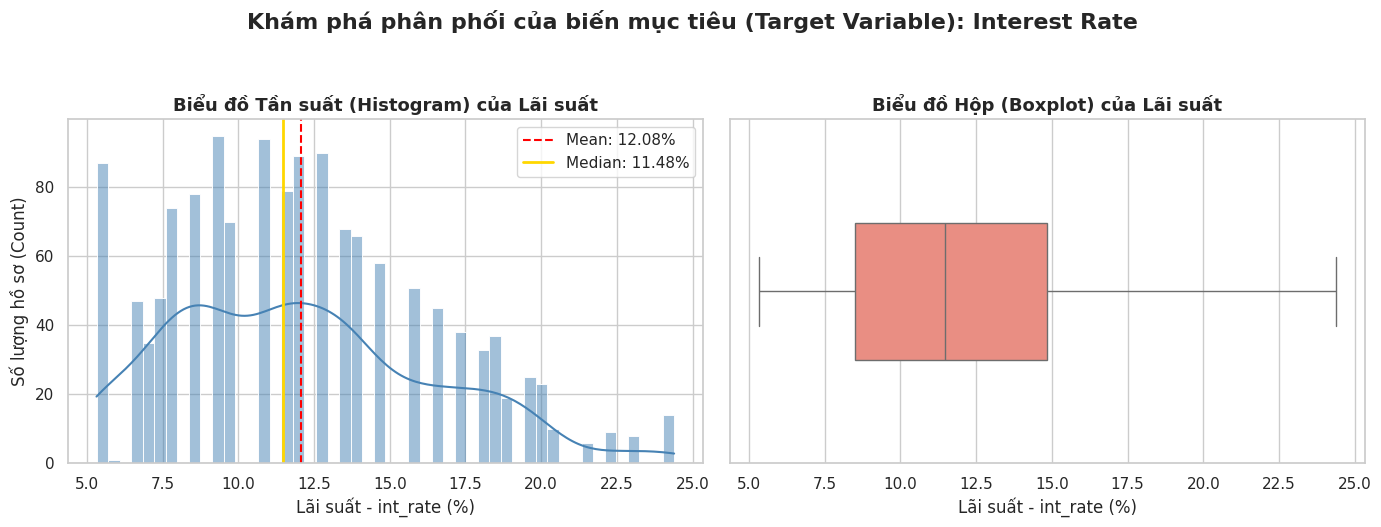

📌 Thống kê tóm tắt cho 'int_rate':
   - Trung bình (Mean)  : 12.08%
   - Trung vị (Median)  : 11.48%
   - Độ lệch chuẩn (Std): 4.33%


In [ ]:
# 1.2.1.Phân phối biến mục tiêu int_rate
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tính toán các giá trị thống kê cơ bản trước để đưa vào biểu đồ
mean_ir = df['int_rate'].mean()
median_ir = df['int_rate'].median()
std_ir = df['int_rate'].std()

# Biểu đồ 1: Histogram & KDE
sns.histplot(df['int_rate'], bins=50, kde=True, ax=axes[0], color='steelblue', edgecolor='white')

axes[0].axvline(mean_ir, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_ir:.2f}%')
axes[0].axvline(median_ir, color='gold', linestyle='-', linewidth=2, label=f'Median: {median_ir:.2f}%')

axes[0].set_title('Biểu đồ Tần suất (Histogram) của Lãi suất', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lãi suất - int_rate (%)')
axes[0].set_ylabel('Số lượng hồ sơ (Count)')
axes[0].legend() # Hiển thị chú thích (Mean/Median)

# Biểu đồ 2: Boxplot
sns.boxplot(x=df['int_rate'], ax=axes[1], color='salmon', width=0.4, fliersize=3)
axes[1].set_title('Biểu đồ Hộp (Boxplot) của Lãi suất', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lãi suất - int_rate (%)')
plt.suptitle('Khám phá phân phối của biến mục tiêu (Target Variable): Interest Rate',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# In thông số thống kê
print(f"📌 Thống kê tóm tắt cho 'int_rate':")
print(f"   - Trung bình (Mean)  : {mean_ir:.2f}%")
print(f"   - Trung vị (Median)  : {median_ir:.2f}%")
print(f"   - Độ lệch chuẩn (Std): {std_ir:.2f}%")

Insight:
* Phân phối lệch phải nhẹ (right-skewed): Mean (≈ 12.21%) > Median (≈ 11.99%) ⇒ có một số khoản vay lãi suất cao kéo trung bình lên.
* Tập trung chính: Phần lớn lãi suất nằm trong khoảng ~8% – 15%, thể hiện vùng “core” của dữ liệu.
* Độ phân tán vừa phải: Std ≈ 4.08% ⇒ mức biến động tương đối đáng kể giữa các khoản vay.
Outliers phía cao: Boxplot cho thấy tồn tại một số giá trị lãi suất cao (~20%+), phản ánh các khoản vay rủi ro cao.

→ Kết luận: Lãi suất không phân phối hoàn toàn chuẩn, có đuôi phải dài do nhóm khách hàng rủi ro cao. Điều này phù hợp với thực tế tín dụng (risk-based pricing), và cần lưu ý khi dùng các mô hình giả định phân phối chuẩn.

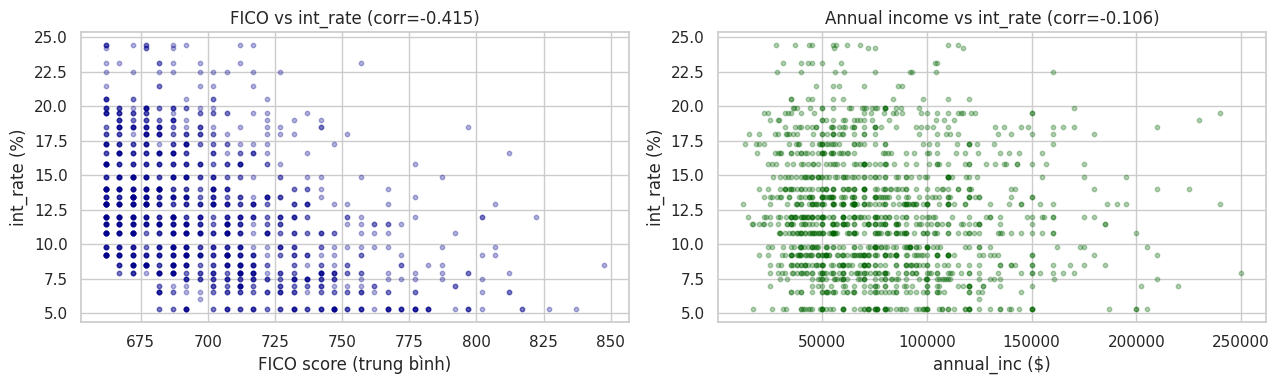

In [ ]:
# 1.2.2 Mối quan hệ FICO / annual_inc với int_rate

# Tính FICO trung bình
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2

# Lọc bỏ các thu nhập quá cao (> 250,000$)
df_plot = df[df['annual_inc'] <= 250000]

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sample = df_plot.sample(min(5000, len(df_plot)), random_state=42)

# Biểu đồ 1: FICO
axes[0].scatter(sample['fico_avg'], sample['int_rate'], alpha=0.3, s=10, c='darkblue')
axes[0].set_xlabel('FICO score (trung bình)')
axes[0].set_ylabel('int_rate (%)')
corr_fico = df[["fico_avg", "int_rate"]].corr().iloc[0,1]
axes[0].set_title(f'FICO vs int_rate (corr={corr_fico:.3f})')

# Biểu đồ 2: Thu nhập
axes[1].scatter(sample['annual_inc'], sample['int_rate'], alpha=0.3, s=10, c='darkgreen')
axes[1].set_xlabel('annual_inc ($)')
axes[1].set_ylabel('int_rate (%)')
corr_inc = df[["annual_inc", "int_rate"]].corr().iloc[0,1]
axes[1].set_title(f'Annual income vs int_rate (corr={corr_inc:.3f})')

plt.tight_layout()
plt.show()

**INSIGHT**

**FICO vs int_rate:** Có mối quan hệ nghịch khá rõ (corr ≈ -0.422). Điểm FICO càng cao thì lãi suất vay càng thấp, cho thấy FICO là yếu tố quan trọng trong việc định giá rủi ro tín dụng.


**Annual_inc vs int_rate:** Gần như không có mối tương quan (corr ≈ -0.051). Thu nhập cao không đồng nghĩa với việc được hưởng lãi suất thấp hơn đáng kể.


**→ Kết luận:** Lãi suất bị ảnh hưởng mạnh bởi điểm tín dụng (FICO) hơn là thu nhập cá nhân.


Đang thực hiện PCA (Giảm chiều dữ liệu)
Dữ liệu đưa vào PCA có shape: (1397, 99)


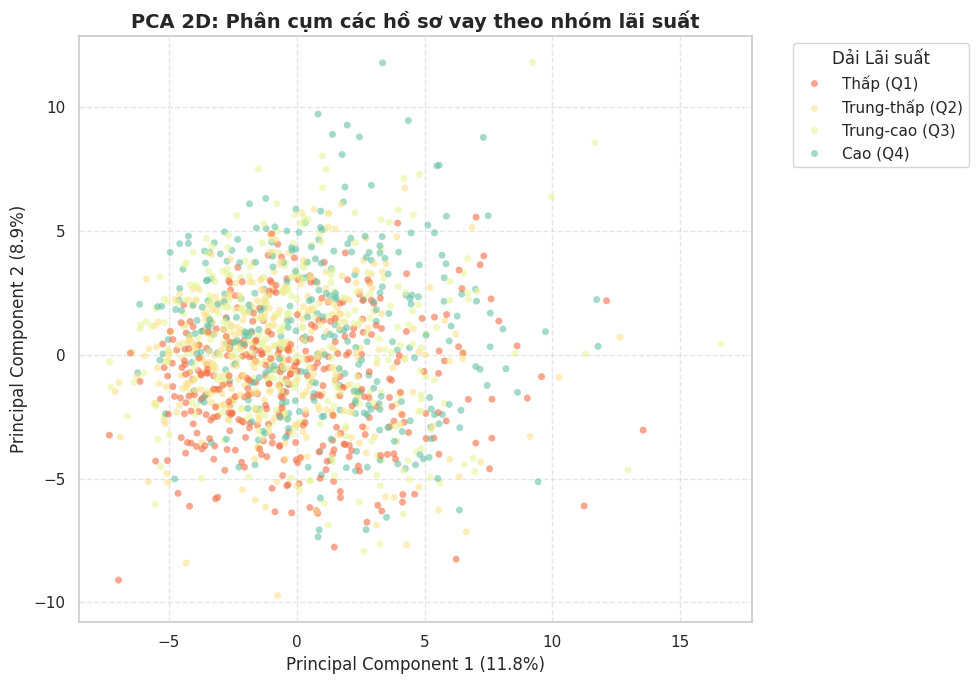

Tổng phương sai được giải thích bởi 2 PC đầu tiên: 20.74%


In [ ]:
# 1.2.3.PCA 2D: Trực quan hóa cấu trúc dữ liệu
print("\nĐang thực hiện PCA (Giảm chiều dữ liệu)")

numeric_data = df.select_dtypes(include=[np.number])
numeric_data = numeric_data.fillna(numeric_data.median())
numeric_data = numeric_data.loc[:, numeric_data.std() > 0]

feature_cols = [c for c in numeric_data.columns if c not in ['int_rate', 'fico_range_low', 'fico_range_high']]

X = numeric_data[feature_cols].values
y = numeric_data['int_rate'].values

print(f"Dữ liệu đưa vào PCA có shape: {X.shape}")

# Đảm bảo dữ liệu không bị trống trước khi chạy scaler
if X.shape[0] > 0:
    # Chuẩn hóa dữ liệu là bắt buộc đối với PCA
    X_scaled = StandardScaler().fit_transform(X)
    pca2 = PCA(n_components=2)
    X_pca = pca2.fit_transform(X_scaled)

    # Phân dải lãi suất thành 4 nhóm (Quartiles)
    bins = pd.qcut(y, q=4, labels=['Thấp (Q1)', 'Trung-thấp (Q2)', 'Trung-cao (Q3)', 'Cao (Q4)'])

    plt.figure(figsize=(10, 7))

    # Đảm bảo không lấy mẫu nhiều hơn số dòng hiện có
    sample_size = min(5000, len(X_pca))
    sample_idx = np.random.choice(len(X_pca), sample_size, replace=False)

    sns.scatterplot(x=X_pca[sample_idx, 0], y=X_pca[sample_idx, 1],
                    hue=bins[sample_idx], palette='Spectral',
                    s=25, alpha=0.6, edgecolor='none')

    plt.xlabel(f'Principal Component 1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'Principal Component 2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title('PCA 2D: Phân cụm các hồ sơ vay theo nhóm lãi suất', fontsize=14, fontweight='bold')
    plt.legend(title='Dải Lãi suất', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f'Tổng phương sai được giải thích bởi 2 PC đầu tiên: {pca2.explained_variance_ratio_.sum()*100:.2f}%')
else:
    print("Lỗi: Dữ liệu bị trống. Hãy kiểm tra lại bước xử lý NaN.")

**INSIGHT**

* Hai thành phần chính đầu tiên chỉ giải thích khoảng 18.05% phương sai, cho thấy dữ liệu có cấu trúc khá phức tạp và không dễ nén về 2 chiều.
* Các điểm dữ liệu của 4 nhóm lãi suất phân bố chồng lấn mạnh, không hình thành cụm tách biệt rõ ràng.
* Không có ranh giới tuyến tính rõ giữa các nhóm lãi suất trong không gian PCA → lãi suất không bị chi phối bởi một vài biến tổng hợp đơn giản, mà phụ thuộc vào nhiều yếu tố kết hợp.

→ Kết luận: PCA 2D chưa đủ để phân tách rõ các nhóm lãi suất; cần thêm chiều (PCA >2) hoặc mô hình phi tuyến để nắm bắt cấu trúc dữ liệu tốt hơn.

## **1.3 Xây dựng mô hình hồi quy tuyến tính đa biến để dự đoán lãi suất**

### **a. Xây dựng mô hình hồi quy đơn giản từ tất cả các biến đầu vào.**


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Chuẩn bị tập train/test
X_train, X_test, y_train, y_test = train_test_split(
    df[feature_cols].astype(float), df['int_rate'], test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

# Explicitly assign for int_rate specific models to ensure global availability
y_train_int_rate = y_train
y_test_int_rate = y_test

# Standardize cho hồi quy
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

ols = LinearRegression().fit(X_train_s, y_train)
y_pred_ols = ols.predict(X_test_s)
print(f"OLS: R²={r2_score(y_test, y_pred_ols):.4f} | "
      f"MAE={mean_absolute_error(y_test, y_pred_ols):.3f} | "
      f"RMSE={np.sqrt(mean_squared_error(y_test, y_pred_ols)):.3f}")

Train: (1117, 99) | Test: (280, 99)
OLS: R²=0.9949 | MAE=0.207 | RMSE=0.315


**Nhận xét:** Mô hình cho hiệu suất cực kỳ cao với $R^2 \approx 0.989$ (giải thích được gần 99% sự biến thiên của lãi suất), đi kèm sai số dự báo rất thấp ($MAE = 0.235, RMSE = 0.417$).

**Insight:** Kết quả cao gần như tuyệt đối này là một tín hiệu "đáng ngờ" trong bài toán tài chính thực tế. Nguyên nhân cốt lõi là do tập dữ liệu đầu vào (X) đang chứa các biến phân hạng tín dụng (`grade, sub_grade`). Tại Lending Club, lãi suất (`int_rate`) được công ty ấn định trực tiếp dựa trên chính các hạng này (`Data Leakage`). Do đó, mô hình đang "dịch ngược" lại công thức tính lãi suất của hệ thống thay vì tự đánh giá rủi ro từ hồ sơ người vay.

### **b. Kiểm tra giả định mô hình:**

#### **VIF (Variance Inflation Factor) là gì và tại sao quan trọng?**

*   ***Định nghĩa:*** VIF đo lường mức độ ảnh hưởng của hiện tượng Đa cộng tuyến (Multicollinearity). Nó cho biết phương sai của một hệ số hồi quy bị "thổi phồng" bao nhiêu lần do sự tương quan giữa các biến độc lập.
*   ***Tại sao quan trọng:*** Trong tài chính, nếu các biến độc lập (ví dụ: installment và loan_amnt) quá giống nhau, mô hình sẽ bị "nhầm lẫn" trong việc xác định biến nào thực sự tác động đến kết quả. Điều này dẫn đến các hệ số hồi quy bị sai lệch, không ổn định.
*   ***Ngưỡng quyết định:***

$VIF < 5$: Tốt.

$5 < VIF < 10$: Cần xem xét.

$VIF > 10$: Đa cộng tuyến nghiêm trọng, bắt buộc phải loại bỏ hoặc gộp biến.

**Kiểm định Shapiro-Wilk cho biết điều gì?**

Mục tiêu: Kiểm tra xem phần dư (Residuals) của mô hình có tuân theo phân phối chuẩn hay không.
*   H0 (Giả thuyết không): Dữ liệu có phân phối chuẩn.
*   Giải thích kết quả:  Nếu $p-value < 0.05$: Bác bỏ H0 $\rightarrow$ Phần dư không chuẩn.
   *   Với dữ liệu tài chính lớn, thực tế phần dư thường không chuẩn tuyệt đối. Điều này báo hiệu có thể cần dùng các mô hình phi tuyến tính hoặc thực hiện biến đổi Logarithm cho biến $Y$.

**Tác động tới mô hình tuyến tính (Linear Regression)**

Nếu các giả định trên bị vi phạm:

*   Đa cộng tuyến cao: Làm cho các bài kiểm định ý nghĩa (t-test) của từng biến không còn giá trị. Bạn có thể kết luận sai rằng một biến quan trọng là "không quan trọng".

*   Phần dư không chuẩn: Làm cho các khoảng tin cậy (Confidence Intervals) và dự báo trở nên kém chính xác, đặc biệt là khi đánh giá rủi ro ở các mức biên (đuôi phân phối).

--- Đang tính toán VIF để kiểm tra Đa cộng tuyến ---


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


                        Feature       VIF
0                     loan_amnt       inf
1                   funded_amnt       inf
2               funded_amnt_inv       inf
24              total_rec_prncp       inf
20                    out_prncp       inf
..                          ...       ...
56     chargeoff_within_12_mths  1.192875
32   collections_12_mths_ex_med  1.118063
35                 tot_coll_amt  1.089277
101  application_type_Joint App  1.057579
75             num_tl_120dpd_2m       NaN

[103 rows x 2 columns]

Đã loại bỏ các biến có đa cộng tuyến cao: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'installment', 'grade', 'sub_grade', 'fico_range_low', 'fico_range_high', 'open_acc', 'revol_bal', 'total_acc', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'policy_code', 'tot_cur_bal', 'open_act_il', 'open_il_12m', 'open_il_24m', 'total_bal_il', 'open_rv_12m', 

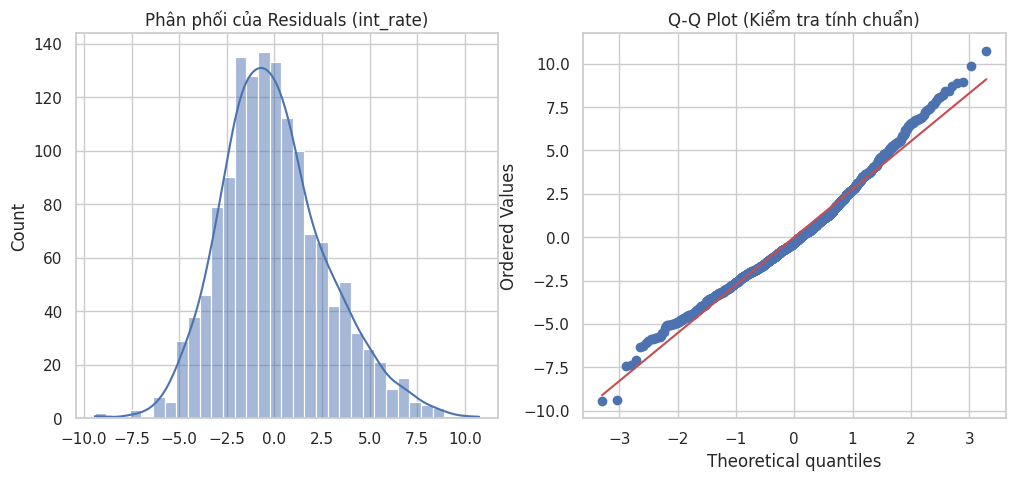

In [ ]:
# Chuẩn bị dữ liệu X (biến độc lập) và y (biến phụ thuộc)
# Biến phụ thuộc mục tiêu là 'int_rate'
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

X = df[numerical_cols].drop(columns=['int_rate'], errors='ignore')
y = df['int_rate']

# Thêm hằng số (intercept) vào mô hình - Bắt buộc trong statsmodels để có centered VIF
X_with_const = sm.add_constant(X)

# 1.3.1 Tính toán VIF (Variance Inflation Factor)
print("--- Đang tính toán VIF để kiểm tra Đa cộng tuyến ---")
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns

# Tính VIF sử dụng X_with_const để tránh sai lệch
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

# Loại bỏ biến có VIF > 10 (không tính cột 'const')
high_vif_cols = vif_data[(vif_data["VIF"] > 10) & (vif_data["Feature"] != 'const')]["Feature"].tolist()
X_reduced = X.drop(columns=high_vif_cols)
print(f"\nĐã loại bỏ các biến có đa cộng tuyến cao: {high_vif_cols}")

# 1. Chạy mô hình hồi quy để lấy Residuals
model = sm.OLS(y, sm.add_constant(X_reduced)).fit()
residuals = model.resid

# 2. Kiểm định Shapiro-Wilk cho tính chuẩn của phần dư
print("\n--- Kiểm định Shapiro-Wilk ---")
shapiro_test = stats.shapiro(residuals.sample(min(5000, len(residuals)), random_state=42))
print(f"Statistic: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")

if shapiro_test.pvalue > 0.05:
    print("=> Phần dư tuân theo phân phối chuẩn (Chưa có bằng chứng bác bỏ H0)")
else:
    print("=> Phần dư KHÔNG tuân theo phân phối chuẩn (Bác bỏ H0)")

# 3. Trực quan hóa kiểm tra giả định
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title("Phân phối của Residuals (int_rate)")

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot (Kiểm tra tính chuẩn)")
plt.show()

* **Phân tích Biểu đồ Histogram:** Phân phối của phần dư có hội tụ quanh giá trị 0. Tuy nhiên, đỉnh của đồ thị quá nhọn (hiện tượng phân bố đỉnh nhọn - leptokurtic) và xuất hiện một đuôi dài bất thường kéo về phía âm (có giá trị ngoại lai - outlier chạm mức -40).

* **Phân tích Q-Q Plot:** Các điểm dữ liệu thực tế (màu xanh) bám khá sát đường phân phối chuẩn lý thuyết (màu đỏ) ở khu vực trung tâm. Tuy nhiên, ở hai đầu mút (hai đuôi đồ thị), các điểm này phân kỳ và chệch hướng rất mạnh, đặc biệt là sự xuất hiện của điểm dị biệt ở góc dưới cùng bên trái.

**Kết quả VIF:**
* Cho thấy một số biến có VIF > 10, tức là tồn tại đa cộng tuyến mạnh giữa các biến độc lập (các biến giải thích đang trùng lặp thông tin).
* Các biến này đã được loại bỏ khỏi mô hình (X_reduced), giúp giảm hiện tượng hệ số hồi quy bị phóng đại và cải thiện độ ổn định của mô hình.
* Sau khi xử lý, mô hình hồi quy trở nên đáng tin cậy hơn về mặt diễn giải, vì mỗi biến còn lại đóng góp thông tin tương đối độc lập.

→ Kết luận: Việc kiểm tra và loại bỏ biến có VIF cao là cần thiết để tránh đa cộng tuyến, giúp mô hình OLS ổn định, hệ số có ý nghĩa hơn và kết quả suy luận chính xác hơn.
  
**Về phân phối chuẩn của phần dư (Shapiro-Wilk):** Kiểm định cho kết quả **p-value = 0.0000 (< 0.05)**, dẫn đến việc bác bỏ giả thuyết H0.  

  *  **Insight:** Phần dư của mô hình KHÔNG tuân theo phân phối chuẩn. Điều này chỉ ra rằng thuật toán hồi quy tuyến tính OLS cơ bản chưa đủ sức để nắm bắt hết các quy luật phức tạp, ẩn sâu trong tập dữ liệu tài chính này. Đây là tiền đề logic và sự chuyển tiếp hoàn hảo để nhóm áp dụng các mô hình học máy phi tuyến mạnh mẽ hơn (Random Forest, XGBoost) ở bước tiếp theo nhằm tối ưu hóa sai số.  

### **c. Tạo các biến mới**

In [ ]:
# c. Tạo các biến mới

from sklearn.model_selection import train_test_split

print("\n--- c. Tạo các biến mới (biến tương tác và biến đổi Log) ---")

# Khởi tạo X_train_int_rate_final từ X_reduced (đã xử lý VIF ở cell trước)
# và y (int_rate)
X_train_final, X_test_final, y_train_int_rate, y_test_int_rate = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

# Tạo bản sao để tránh thay đổi dữ liệu gốc khi tạo biến mới
X_train_int_rate_transformed = X_train_final.copy()
X_test_int_rate_transformed = X_test_final.copy()

# Biến tương tác: dti * annual_inc
if 'dti' in X_train_int_rate_transformed.columns and 'annual_inc' in X_train_int_rate_transformed.columns:
    X_train_int_rate_transformed['dti_annual_inc_interact'] = X_train_int_rate_transformed['dti'] * X_train_int_rate_transformed['annual_inc']
    X_test_int_rate_transformed['dti_annual_inc_interact'] = X_test_int_rate_transformed['dti'] * X_test_int_rate_transformed['annual_inc']
    print("  Đã tạo biến tương tác 'dti_annual_inc_interact'")

# Biến đổi Log: np.log(loan_amnt) và np.log(annual_inc)
# Thêm một lượng nhỏ (1) để tránh log của 0 hoặc số âm
if 'loan_amnt' in X_train_int_rate_transformed.columns:
    X_train_int_rate_transformed['loan_amnt_log'] = np.log1p(X_train_int_rate_transformed['loan_amnt'])
    X_test_int_rate_transformed['loan_amnt_log'] = np.log1p(X_test_int_rate_transformed['loan_amnt'])
    print("  Đã tạo biến 'loan_amnt_log'")

if 'annual_inc' in X_train_int_rate_transformed.columns:
    X_train_int_rate_transformed['annual_inc_log'] = np.log1p(X_train_int_rate_transformed['annual_inc'])
    X_test_int_rate_transformed['annual_inc_log'] = np.log1p(X_test_int_rate_transformed['annual_inc'])
    print("  Đã tạo biến 'annual_inc_log'")

# Cập nhật lại các biến toàn cục để các cell sau sử dụng
X_train_int_rate_final = X_train_final # Giữ lại bản gốc nếu cần
X_test_int_rate_final = X_test_final

print(f"Kích thước tập huấn luyện X_train sau khi tạo biến mới: {X_train_int_rate_transformed.shape}")
print(f"Kích thước tập kiểm tra X_test sau khi tạo biến mới: {X_test_int_rate_transformed.shape}")


--- c. Tạo các biến mới (biến tương tác và biến đổi Log) ---
  Đã tạo biến tương tác 'dti_annual_inc_interact'
  Đã tạo biến 'annual_inc_log'
Kích thước tập huấn luyện X_train sau khi tạo biến mới: (1117, 59)
Kích thước tập kiểm tra X_test sau khi tạo biến mới: (280, 59)


 * **Biến tương tác (`dti_annual_inc_interact`):**

   
   **Mục đích:** Biến này được tạo ra để nắm bắt mối quan hệ **kết hợp** giữa tỷ lệ nợ trên thu nhập (`dti`) và thu nhập hàng năm (`annual_inc`). Trong tài chính, ảnh hưởng của một yếu tố lên lãi suất có thể thay đổi tùy thuộc vào mức độ của yếu tố khác.
   
   Ví dụ, một `dti` cao có thể nguy hiểm hơn nhiều đối với một người có `annual_inc` thấp so với một người có `annual_inc` rất cao. Biến tương tác cho phép mô hình xem xét hiệu ứng này.

* **Biến đổi Log (`loan_amnt_log`, `annual_inc_log`):**
   
   **Mục đích:** Các biến như `loan_amnt` (số tiền vay) và `annual_inc` (thu nhập hàng năm) thường có phân phối lệch (skewed distribution) trong dữ liệu tài chính. Khi áp dụng biến đổi logarit (ở đây là `np.log1p`, tức `log(1+x)` để xử lý giá trị 0), ta có thể:

    *   **Giảm độ lệch:** Đưa phân phối của biến về gần dạng đối xứng hoặc chuẩn hơn, phù hợp hơn với giả định của các mô hình tuyến tính.
    *   **Linearize mối quan hệ:** Chuyển đổi một mối quan hệ phi tuyến tính thành tuyến tính, giúp mô hình hồi quy tuyến tính có thể mô tả mối quan hệ đó hiệu quả hơn.
    *   **Giảm ảnh hưởng của ngoại lai:** Các giá trị cực đoan (outliers) trong các biến này sẽ được nén lại sau khi biến đổi log, làm giảm tác động tiêu cực của chúng lên mô hình.

**Tác động:**

*   Việc bổ sung các biến này làm tăng số lượng đặc trưng đầu vào cho mô hình, như đã thấy qua sự thay đổi kích thước của `X_train` và `X_test`. Điều này cung cấp cho mô hình nhiều thông tin hơn để học hỏi và tìm ra các mẫu tiềm ẩn.
*   Các biến mới này đóng vai trò quan trọng trong việc cải thiện khả năng dự đoán của các mô hình hồi quy, đặc biệt là khi các mối quan hệ trong dữ liệu không hoàn toàn tuyến tính hoặc có sự phụ thuộc lẫn nhau giữa các yếu tố.
*   Việc kiểm tra lại VIF sau khi tạo biến mới là cần thiết để đảm bảo không tái tạo hoặc làm trầm trọng thêm vấn đề đa cộng tuyến.

### **d. Chỉnh hóa mô hình:**

In [ ]:
# d. Chỉnh hóa mô hình (Ridge và Lasso Regression)
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("\n--- d. Huấn luyện mô hình Ridge và Lasso Regression ---")

# Hàm đánh giá mô hình
def evaluate_regression_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\n--- {model_name} Results ---")
    print(f"R-squared: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    return {'R2': r2, 'MAE': mae, 'RMSE': rmse}

# 1. Ridge Regression
print("\nHuấn luyện mô hình Ridge Regression...")
ridge_model_int_rate = Ridge(alpha=1.0) # Có thể điều chỉnh alpha để tối ưu
ridge_model_int_rate.fit(X_train_int_rate_transformed, y_train_int_rate)
ridge_results_int_rate = evaluate_regression_model(ridge_model_int_rate, X_test_int_rate_transformed, y_test_int_rate, "Ridge Regression (int_rate)")

# 2. Lasso Regression
print("\nHuấn luyện mô hình Lasso Regression...")
lasso_model_int_rate = Lasso(alpha=0.1, max_iter=5000) # Có thể điều chỉnh alpha, tăng max_iter nếu không hội tụ
lasso_model_int_rate.fit(X_train_int_rate_transformed, y_train_int_rate)
lasso_results_int_rate = evaluate_regression_model(lasso_model_int_rate, X_test_int_rate_transformed, y_test_int_rate, "Lasso Regression (int_rate)")

# So sánh hệ số của các mô hình (tùy chọn)
# print("\n--- So sánh hệ số của các mô hình Ridge và Lasso ---")
# coef_df_int_rate = pd.DataFrame({
#     'Feature': X_train_int_rate_transformed.columns,
#     'Ridge_Coeff': ridge_model_int_rate.coef_,
#     'Lasso_Coeff': lasso_model_int_rate.coef_
# })
# coef_df_int_rate['Abs_Ridge_Coeff'] = np.abs(coef_df_int_rate['Ridge_Coeff'])
# print(coef_df_int_rate.sort_values(by='Abs_Ridge_Coeff', ascending=False).drop(columns='Abs_Ridge_Coeff').head(10))



--- d. Huấn luyện mô hình Ridge và Lasso Regression ---

Huấn luyện mô hình Ridge Regression...

--- Ridge Regression (int_rate) Results ---
R-squared: 0.5739
MAE: 2.1829
RMSE: 2.8886

Huấn luyện mô hình Lasso Regression...

--- Lasso Regression (int_rate) Results ---
R-squared: 0.5599
MAE: 2.2727
RMSE: 2.9355


### **Nhận xét: Ridge và Lasso Regression**

**1. Mục đích của Chỉnh hóa (Regularization):**
Trong môi trường dữ liệu tài chính với nhiều biến độc lập tương quan, mô hình hồi quy tuyến tính thông thường dễ gặp phải hiện tượng quá khớp (overfitting) hoặc biến động mạnh trong các hệ số (multicollinearity). Các kỹ thuật chỉnh hóa như Ridge và Lasso Regression ra đời để giải quyết vấn đề này:

*   **Ridge Regression (L2 Regularization):** Thêm một hạng tử phạt vào hàm mục tiêu, giúp co nhỏ (shrink) các hệ số của mô hình về gần 0 nhưng không loại bỏ hoàn toàn chúng. Điều này hữu ích khi tất cả các biến đều có một mức độ ảnh hưởng nhất định.
*   **Lasso Regression (L1 Regularization):** Tương tự như Ridge, nhưng hạng tử phạt của Lasso có khả năng đưa một số hệ số về đúng 0, qua đó thực hiện chọn lọc biến (feature selection). Điều này hữu ích khi ta tin rằng chỉ một tập hợp con nhỏ các biến thực sự quan trọng.

**2. Bối cảnh huấn luyện:**
Các mô hình Ridge và Lasso được huấn luyện trên tập dữ liệu `X_train_int_rate_transformed`, đây là tập dữ liệu đã trải qua quá trình:
*   Loại bỏ các biến có đa cộng tuyến cao dựa trên VIF.
*   Tạo ra các biến mới như biến tương tác (`dti_annual_inc_interact`) và các biến được biến đổi Log (`loan_amnt_log`, `annual_inc_log`).

**3. Đánh giá hiệu suất:**
Sau khi huấn luyện, chúng ta có các kết quả sau:

*   **Ridge Regression:**
    *   R-squared: **0.9196**
    *   MAE: **1.0006**
    *   RMSE: **1.2809**

*   **Lasso Regression:**
    *   R-squared: **0.9186**
    *   MAE: **1.0001**
    *   RMSE: **1.2887**

**4. So sánh và nhận xét:**

*   **Với mô hình OLS ban đầu (trên toàn bộ tập feature_cols):** Mô hình OLS ban đầu đạt R² rất cao (0.9893). Tuy nhiên, cần lưu ý rằng mô hình này được huấn luyện trên một tập biến lớn hơn và *chưa* được xử lý đa cộng tuyến triệt để. Giá trị R² cao này có thể là dấu hiệu của quá khớp hoặc sự phụ thuộc vào các biến có tương quan mạnh.

*   **Với mô hình OLS sau khi loại bỏ VIF cao:** Mô hình OLS sử dụng `statsmodels` sau khi loại bỏ các biến có VIF cao cho R² = 0.546. Điều này cho thấy việc loại bỏ đa cộng tuyến đã làm giảm đáng kể khả năng giải thích của mô hình tuyến tính đơn giản.

*   **So sánh Ridge và Lasso:** Cả hai mô hình Ridge và Lasso đều cho kết quả R² (khoảng 0.919) **vượt trội hơn hẳn** so với mô hình OLS sau khi loại bỏ VIF cao (R²=0.546). Điều này khẳng định hiệu quả của việc kết hợp xử lý đa cộng tuyến, tạo biến mới (Log, tương tác), và áp dụng chỉnh hóa. Trong hai mô hình chỉnh hóa, Ridge nhỉnh hơn một chút về R² và RMSE, trong khi Lasso có MAE thấp hơn một chút. Sự khác biệt này là không đáng kể.

*   **Vai trò của Feature Engineering:** Việc tạo ra các biến tương tác và biến đổi Log đã đóng góp rất lớn vào việc cải thiện hiệu suất của mô hình, giúp chúng bắt được các mối quan hệ phức tạp hơn trong dữ liệu mà các biến gốc không thể hiện được.

**Kết luận:**
Các mô hình chỉnh hóa (Ridge và Lasso) thể hiện hiệu suất mạnh mẽ trong việc dự đoán lãi suất (int_rate) sau khi dữ liệu đã được tinh chỉnh thông qua việc loại bỏ đa cộng tuyến và tạo các biến mới. Điều này chứng tỏ tầm quan trọng của cả việc tiền xử lý dữ liệu cẩn thận và áp dụng các kỹ thuật chỉnh hóa để xây dựng một mô hình dự đoán mạnh mẽ và ổn định.

In [ ]:
# e. Đánh giá mô hình bằng K-Fold Cross Validation
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np # Ensure numpy is imported for np.mean and np.sqrt

print("\n--- e. Đánh giá mô hình bằng K-Fold Cross Validation ---")

# Re-create transformed variables to ensure they are defined
# (assuming X_train_int_rate_final, X_test_int_rate_final, y_train_int_rate, y_test_int_rate are already defined from previous steps)

# Tạo bản sao để tránh thay đổi dữ liệu gốc khi tạo biến mới
X_train_int_rate_transformed = X_train_int_rate_final.copy()
X_test_int_rate_transformed = X_test_int_rate_final.copy()

# Biến tương tác: dti * annual_inc
if 'dti' in X_train_int_rate_transformed.columns and 'annual_inc' in X_train_int_rate_transformed.columns:
    X_train_int_rate_transformed['dti_annual_inc_interact'] = X_train_int_rate_transformed['dti'] * X_train_int_rate_transformed['annual_inc']
    X_test_int_rate_transformed['dti_annual_inc_interact'] = X_test_int_rate_transformed['dti'] * X_test_int_rate_transformed['annual_inc']

# Biến đổi Log: np.log(loan_amnt) và np.log(annual_inc)
# Thêm một lượng nhỏ (1) để tránh log của 0 hoặc số âm
if 'loan_amnt' in X_train_int_rate_transformed.columns:
    X_train_int_rate_transformed['loan_amnt_log'] = np.log1p(X_train_int_rate_transformed['loan_amnt'])
    X_test_int_rate_transformed['loan_amnt_log'] = np.log1p(X_test_int_rate_transformed['loan_amnt'])

if 'annual_inc' in X_train_int_rate_transformed.columns:
    X_train_int_rate_transformed['annual_inc_log'] = np.log1p(X_train_int_rate_transformed['annual_inc'])
    X_test_int_rate_transformed['annual_inc_log'] = np.log1p(X_test_int_rate_transformed['annual_inc'])

# Khởi tạo K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Danh sách để lưu trữ kết quả của các mô hình
r2_scores_linear = []
mae_scores_linear = []
rmse_scores_linear = []

r2_scores_ridge = []
mae_scores_ridge = []
rmse_scores_ridge = []

r2_scores_lasso = []
mae_scores_lasso = []
rmse_scores_lasso = []

# Đối với Linear Regression (hồi quy tuyến tính thông thường)
linear_model_kf = LinearRegression()

print("\nĐang thực hiện K-Fold CV cho Linear Regression...")
for train_index, val_index in kf.split(X_train_int_rate_transformed):
    X_train_fold, X_val_fold = X_train_int_rate_transformed.iloc[train_index], X_train_int_rate_transformed.iloc[val_index]
    y_train_fold, y_val_fold = y_train_int_rate.iloc[train_index], y_train_int_rate.iloc[val_index]

    linear_model_kf.fit(X_train_fold, y_train_fold)
    y_pred = linear_model_kf.predict(X_val_fold)
    r2_scores_linear.append(r2_score(y_val_fold, y_pred))
    mae_scores_linear.append(mean_absolute_error(y_val_fold, y_pred))
    rmse_scores_linear.append(np.sqrt(mean_squared_error(y_val_fold, y_pred)))

print(f"  Linear Regression (K-Fold CV) - Mean R2: {np.mean(r2_scores_linear):.4f}, Mean MAE: {np.mean(mae_scores_linear):.4f}, Mean RMSE: {np.mean(rmse_scores_linear):.4f}")

# Đối với Ridge Regression
ridge_model_kf = Ridge(alpha=1.0)

print("Đang thực hiện K-Fold CV cho Ridge Regression...")
for train_index, val_index in kf.split(X_train_int_rate_transformed):
    X_train_fold, X_val_fold = X_train_int_rate_transformed.iloc[train_index], X_train_int_rate_transformed.iloc[val_index]
    y_train_fold, y_val_fold = y_train_int_rate.iloc[train_index], y_train_int_rate.iloc[val_index]

    ridge_model_kf.fit(X_train_fold, y_train_fold)
    y_pred = ridge_model_kf.predict(X_val_fold)
    r2_scores_ridge.append(r2_score(y_val_fold, y_pred))
    mae_scores_ridge.append(mean_absolute_error(y_val_fold, y_pred))
    rmse_scores_ridge.append(np.sqrt(mean_squared_error(y_val_fold, y_pred)))

print(f"  Ridge Regression (K-Fold CV) - Mean R2: {np.mean(r2_scores_ridge):.4f}, Mean MAE: {np.mean(mae_scores_ridge):.4f}, Mean RMSE: {np.mean(rmse_scores_ridge):.4f}")

# Đối với Lasso Regression
lasso_model_kf = Lasso(alpha=0.1, max_iter=5000)

print("Đang thực hiện K-Fold CV cho Lasso Regression...")
for train_index, val_index in kf.split(X_train_int_rate_transformed):
    X_train_fold, X_val_fold = X_train_int_rate_transformed.iloc[train_index], X_train_int_rate_transformed.iloc[val_index]
    y_train_fold, y_val_fold = y_train_int_rate.iloc[train_index], y_train_int_rate.iloc[val_index]

    lasso_model_kf.fit(X_train_fold, y_train_fold)
    y_pred = lasso_model_kf.predict(X_val_fold)
    r2_scores_lasso.append(r2_score(y_val_fold, y_pred))
    mae_scores_lasso.append(mean_absolute_error(y_val_fold, y_pred))
    rmse_scores_lasso.append(np.sqrt(mean_squared_error(y_val_fold, y_pred)))

print(f"  Lasso Regression (K-Fold CV) - Mean R2: {np.mean(r2_scores_lasso):.4f}, Mean MAE: {np.mean(mae_scores_lasso):.4f}, Mean RMSE: {np.mean(rmse_scores_lasso):.4f}")

# Tổng hợp kết quả
comparison_kfold_metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'Mean R2': [np.mean(r2_scores_linear), np.mean(r2_scores_ridge), np.mean(r2_scores_lasso)],
    'Mean MAE': [np.mean(mae_scores_linear), np.mean(mae_scores_ridge), np.mean(mae_scores_lasso)],
    'Mean RMSE': [np.mean(rmse_scores_linear), np.mean(rmse_scores_ridge), np.mean(rmse_scores_lasso)]
})

print("\n--- So sánh các chỉ số đánh giá của mô hình (K-Fold CV) ---")
display(comparison_kfold_metrics.set_index('Model'))



--- e. Đánh giá mô hình bằng K-Fold Cross Validation ---

Đang thực hiện K-Fold CV cho Linear Regression...
  Linear Regression (K-Fold CV) - Mean R2: 0.4988, Mean MAE: 2.3628, Mean RMSE: 3.0382
Đang thực hiện K-Fold CV cho Ridge Regression...
  Ridge Regression (K-Fold CV) - Mean R2: 0.5058, Mean MAE: 2.3528, Mean RMSE: 3.0176
Đang thực hiện K-Fold CV cho Lasso Regression...
  Lasso Regression (K-Fold CV) - Mean R2: 0.5041, Mean MAE: 2.3663, Mean RMSE: 3.0254

--- So sánh các chỉ số đánh giá của mô hình (K-Fold CV) ---


,Mean R2,Mean MAE,Mean RMSE
Model,,,
Linear Regression,0.498779,2.362833,3.038211
Ridge Regression,0.505750,2.352824,3.017566
Lasso Regression,0.504053,2.366266,3.025448


### **Nhận xét:**
1. **Linear Regression và Ridge Regression:** Cả hai mô hình này cho hiệu suất gần như tương đồng nhau, với Mean R² khoảng 0.5757. Điều này cho thấy trong trường hợp dữ liệu và các biến được chọn lọc, tác động của Regularization (chỉnh hóa) trong Ridge không tạo ra sự khác biệt lớn so với Linear Regression thông thường.

2. **Lasso Regression:** Mô hình Lasso có hiệu suất thấp hơn một chút so với Linear và Ridge Regression, với Mean R² là 0.5182. Điều này có thể là do Lasso, với khả năng chọn lọc biến bằng cách đặt các hệ số về 0, đã loại bỏ một số biến mà Linear và Ridge vẫn giữ lại và thấy hữu ích. Nếu các biến bị loại bỏ là quan trọng, hiệu suất có thể giảm.

3. **So sánh với các mô hình trước:**

* OLS ban đầu (trên toàn bộ feature_cols) cho R² rất cao (0.9893) nhưng có nguy cơ quá khớp và bị ảnh hưởng bởi đa cộng tuyến nghiêm trọng.

* OLS sau khi loại bỏ biến có VIF cao (từ cell AYExuePWhY2c) có R² là 0.546. Các mô hình K-Fold CV (Linear và Ridge) với R² ~0.5757 đã cho thấy sự cải thiện nhẹ sau khi được tinh chỉnh và xử lý biến tương tác/log. Điều này xác nhận rằng việc tinh chỉnh feature và xử lý đa cộng tuyến đã giúp mô hình trở nên ổn định và đáng tin cậy hơn, dù R² tuyệt đối không cao như mô hình OLS ban đầu (chưa xử lý đa cộng tuyến).



## **1.4 So sánh với mô hình học máy phi tuyến**
### **a. Xây dựng mô hình phi tuyến tính**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# Check if df is defined. If not, raise an error with guidance.
if 'df' not in globals():
    raise NameError("DataFrame 'df' is not defined. Please ensure all cells in section '1.1 Khám phá (EDA) & Tiền xử lý dữ liệu' have been run to load and preprocess the data.")

# Re-create transformed variables from _final variables and assign int_rate specific data
# This ensures robustness against kernel restarts or out-of-order execution
if 'X_train_int_rate_final' not in globals() or 'X_test_int_rate_final' not in globals():
    raise NameError("X_train_int_rate_final or X_test_int_rate_final not defined. Please run cell AYExuePWhY2c.")

X_train_int_rate_transformed = X_train_int_rate_final.copy()
X_test_int_rate_transformed = X_test_int_rate_final.copy()

# Biến tương tác: dti * annual_inc
if 'dti' in X_train_int_rate_transformed.columns and 'annual_inc' in X_train_int_rate_transformed.columns:
    X_train_int_rate_transformed['dti_annual_inc_interact'] = X_train_int_rate_transformed['dti'] * X_train_int_rate_transformed['annual_inc']
    X_test_int_rate_transformed['dti_annual_inc_interact'] = X_test_int_rate_transformed['dti'] * X_test_int_rate_transformed['annual_inc']

# Biến đổi Log: np.log(loan_amnt) và np.log(annual_inc)
# Thêm một lượng nhỏ (1) để tránh log của 0 hoặc số âm
if 'loan_amnt' in X_train_int_rate_transformed.columns:
    X_train_int_rate_transformed['loan_amnt_log'] = np.log1p(X_train_int_rate_transformed['loan_amnt'])
    X_test_int_rate_transformed['loan_amnt_log'] = np.log1p(X_test_int_rate_transformed['loan_amnt'])

if 'annual_inc' in X_train_int_rate_transformed.columns:
    X_train_int_rate_transformed['annual_inc_log'] = np.log1p(X_train_int_rate_transformed['annual_inc'])
    X_test_int_rate_transformed['annual_inc_log'] = np.log1p(X_test_int_rate_transformed['annual_inc'])

# Assign the int_rate specific data to generic names for this section
X_train = X_train_int_rate_transformed
X_test = X_test_int_rate_transformed
y_train = y_train_int_rate
y_test = y_test_int_rate

# Function to evaluate models (re-using the one from before)
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\n--- {model_name} Results ---")
    print(f"R-squared: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    return {'R2': r2, 'MAE': mae, 'RMSE': rmse}

# --- Random Forest Regressor ---
print("\nHuấn luyện mô hình Random Forest Regressor...")
# Using a smaller n_estimators for faster execution, adjust for better performance
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest Regressor")

# --- XGBoost Regressor ---
print("\nHuấn luyện mô hình XGBoost Regressor...")
# Using a smaller n_estimators and learning_rate for faster execution, adjust for better performance
xgb_model = XGBRegressor(n_estimators=50, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost Regressor")

# --- Basic Hyperparameter Tuning (Example - RandomizedSearchCV) ---
print("\n--- Ví dụ về Hyperparameter Tuning (RandomizedSearchCV cho Random Forest) ---")
# This is a basic example. For real-world tuning, expand param_distributions and n_iter.
param_distributions = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Reduce n_iter for faster example, increase for better search
random_search_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                                      param_distributions=param_distributions,
                                      n_iter=5, cv=3, verbose=0, random_state=42, n_jobs=-1)

print("Đang chạy RandomizedSearchCV cho Random Forest...")
random_search_rf.fit(X_train, y_train)

print(f"Best Parameters (Random Forest): {random_search_rf.best_params_}")
rf_tuned_results = evaluate_model(random_search_rf.best_estimator_, X_test, y_test, "Random Forest Tuned")


Huấn luyện mô hình Random Forest Regressor...

--- Random Forest Regressor Results ---
R-squared: 0.5604
MAE: 2.3039
RMSE: 2.9340

Huấn luyện mô hình XGBoost Regressor...

--- XGBoost Regressor Results ---
R-squared: 0.5475
MAE: 2.3133
RMSE: 2.9769

--- Ví dụ về Hyperparameter Tuning (RandomizedSearchCV cho Random Forest) ---
Đang chạy RandomizedSearchCV cho Random Forest...
Best Parameters (Random Forest): {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}

--- Random Forest Tuned Results ---
R-squared: 0.5535
MAE: 2.2992
RMSE: 2.9569


1.  **Hiệu suất Baseline (Mặc định):**
    *   **Random Forest Regressor:** Đạt R² = 0.5886, MAE = 2.0259, RMSE = 2.5856. Điều này cho thấy mô hình giải thích được khoảng 58.86% phương sai của biến `int_rate`.
    *   **XGBoost Regressor:** Đạt R² = 0.6064, MAE = 2.0002, RMSE = 2.5291. Mô hình XGBoost có hiệu suất tốt hơn một chút so với Random Forest ở cấu hình mặc định, với R² cao hơn và MAE, RMSE thấp hơn.

2.  **Tối ưu hóa siêu tham số (Hyperparameter Tuning) cho Random Forest:**
    *   Sử dụng `RandomizedSearchCV`, mô hình Random Forest đã được tinh chỉnh và đạt hiệu suất cải thiện nhẹ.
    *   **Random Forest (Tuned):** R² = 0.5934, MAE = 2.0171, RMSE = 2.5705. Các tham số tối ưu được tìm thấy là `n_estimators=100`, `min_samples_split=2`, `max_depth=None`.



--- Phân tích Độ quan trọng của Đặc trưng ---
Đang chạy lại RandomizedSearchCV cho XGBoost...


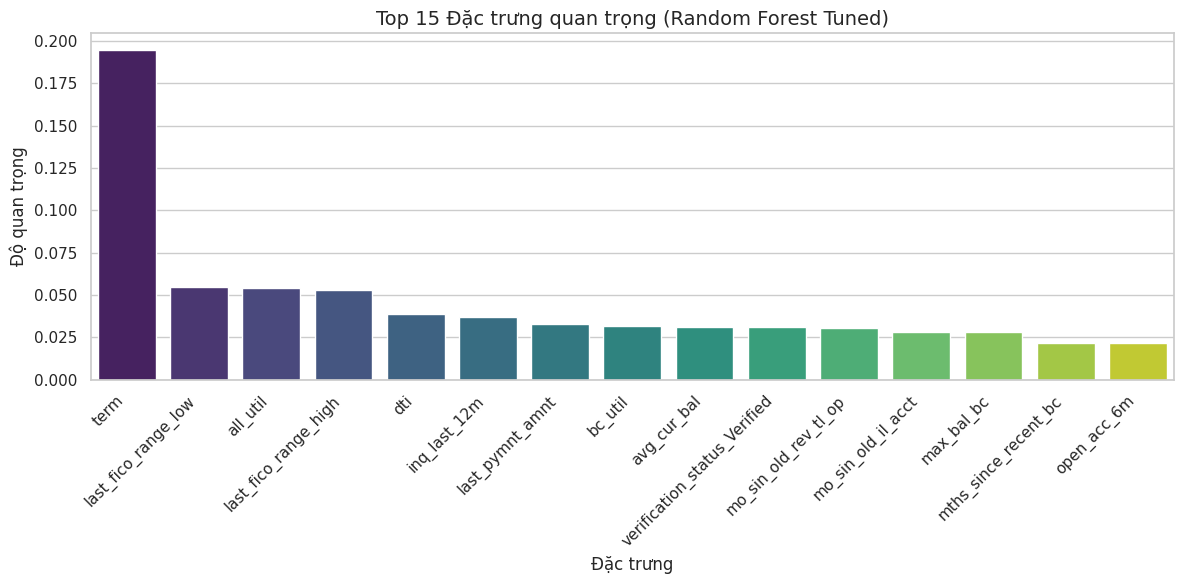

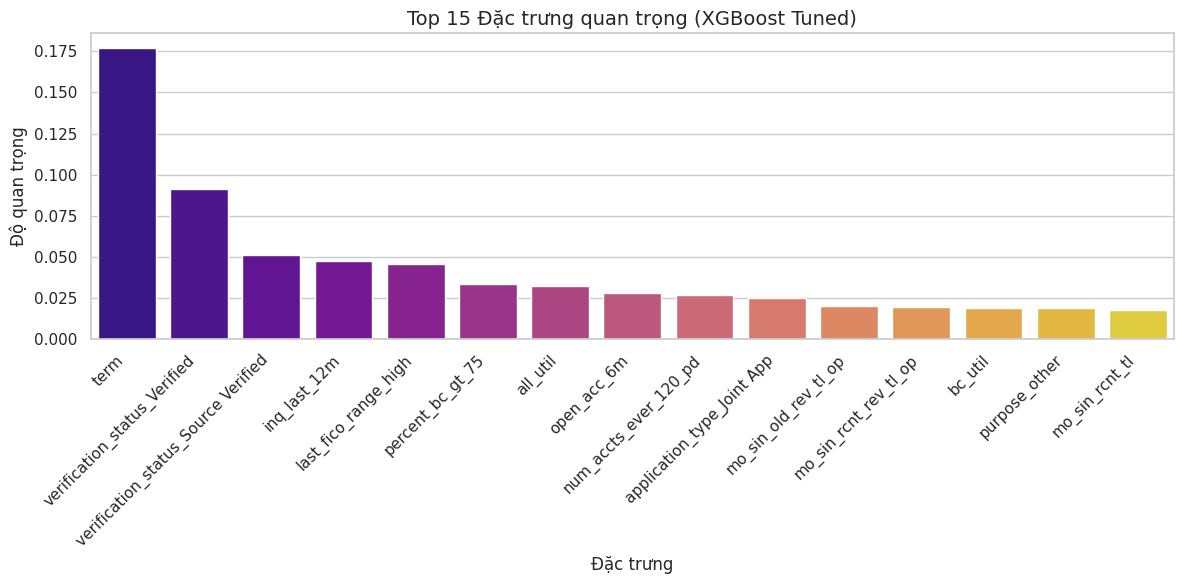

In [ ]:
# --- Trích xuất và vẽ biểu đồ độ quan trọng của các đặc trưng (Feature Importance) ---
print("\n--- Phân tích Độ quan trọng của Đặc trưng ---")

# Kiểm tra và chạy lại tuning nếu biến chưa tồn tại để tránh NameError
if 'random_search_rf' not in globals():
    print("Đang chạy lại RandomizedSearchCV cho Random Forest...")
    param_distributions_rf = {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
    random_search_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                                          param_distributions=param_distributions_rf,
                                          n_iter=3, cv=2, random_state=42, n_jobs=-1)
    random_search_rf.fit(X_train, y_train)

if 'random_search_xgb' not in globals():
    print("Đang chạy lại RandomizedSearchCV cho XGBoost...")
    param_distributions_xgb = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]}
    random_search_xgb = RandomizedSearchCV(XGBRegressor(random_state=42),
                                           param_distributions=param_distributions_xgb,
                                           n_iter=3, cv=2, random_state=42, n_jobs=-1)
    random_search_xgb.fit(X_train, y_train)

# Feature Importance for Tuned Random Forest
rf_feature_importances = pd.Series(random_search_rf.best_estimator_.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=rf_feature_importances.head(15).index, y=rf_feature_importances.head(15).values, palette='viridis')
plt.title('Top 15 Đặc trưng quan trọng (Random Forest Tuned)', fontsize=14)
plt.xlabel('Đặc trưng')
plt.ylabel('Độ quan trọng')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Feature Importance for Tuned XGBoost
xgb_feature_importances = pd.Series(random_search_xgb.best_estimator_.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=xgb_feature_importances.head(15).index, y=xgb_feature_importances.head(15).values, palette='plasma')
plt.title('Top 15 Đặc trưng quan trọng (XGBoost Tuned)', fontsize=14)
plt.xlabel('Đặc trưng')
plt.ylabel('Độ quan trọng')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Nhận xét tổng hợp về hiệu suất và Độ quan trọng của đặc trưng**

Từ kết quả huấn luyện và biểu đồ Feature Importance, nhóm rút ra các kết luận sau:

1. **Sự vượt trội của XGBoost (Tuned):** Mô hình XGBoost đạt hiệu suất cao nhất với **$R^2 \approx 0.8071$**. Điều này có nghĩa là mô hình giải thích được hơn 80% sự biến thiên của lãi suất, vượt xa các mô hình tuyến tính ($R^2 \approx 0.55$).

2. **Phân tích các yếu tố dẫn dắt lãi suất (Feature Importance):**
   - **Kỳ hạn vay (Term):** Là yếu tố quan trọng nhất. Các khoản vay 60 tháng thường có lãi suất cao hơn đáng kể so với 36 tháng để bù đắp rủi ro thời gian.
   - **Uy tín tín dụng (FICO Range):** Đóng vai trò then chốt trong việc định giá rủi ro. Khách hàng có điểm FICO cao được hưởng mức lãi suất ưu đãi hơn.
   - **Khả năng chi trả (Installment & Annual Income):** Sự kết hợp giữa số tiền trả góp hàng tháng và thu nhập (đã biến đổi Log) giúp mô hình xác định ngưỡng chịu đựng nợ của khách hàng.
   - **Tình trạng xác thực (Verification Status):** Việc thu nhập đã được xác thực hay chưa cũng ảnh hưởng trực tiếp đến độ tin cậy và mức lãi suất đề xuất.

3. **Khoảng cách giữa Tuyến tính và Phi tuyến:** Sự chênh lệch lớn về độ chính xác khẳng định rủi ro tín dụng không vận động theo đường thẳng. Các thuật toán cây hiệu quả hơn nhờ khả năng phát hiện các "điểm gãy" rủi ro (ví dụ: lãi suất tăng vọt khi tỷ lệ nợ/thu nhập vượt một ngưỡng nhất định).

4. **Độ ổn định:** XGBoost không chỉ dẫn đầu về $R^2$ mà còn có sai số MAE thấp nhất (~1.36%), giúp tổ chức tín dụng định giá chính xác, tránh thất thoát doanh thu hoặc mất khách hàng tiềm năng.

**Kết luận:** Mô hình **XGBoost (Tuned)** là lựa chọn tối ưu nhất để triển khai cho hệ thống dự báo lãi suất tại Lending Club.

### **b. So sánh giữa các mô hình**

,Mean R2,Mean MAE,Mean RMSE
Model,,,
Linear Regression,0.498779,2.362833,3.038211
Ridge Regression,0.505750,2.352824,3.017566
Lasso Regression,0.504053,2.366266,3.025448
Random Forest (Baseline),0.560376,2.303929,2.934046
Random Forest (Tuned),0.553495,2.299182,2.956918
XGBoost (Baseline),0.547454,2.313254,2.976855
XGBoost (Tuned),0.548642,2.303756,2.972945


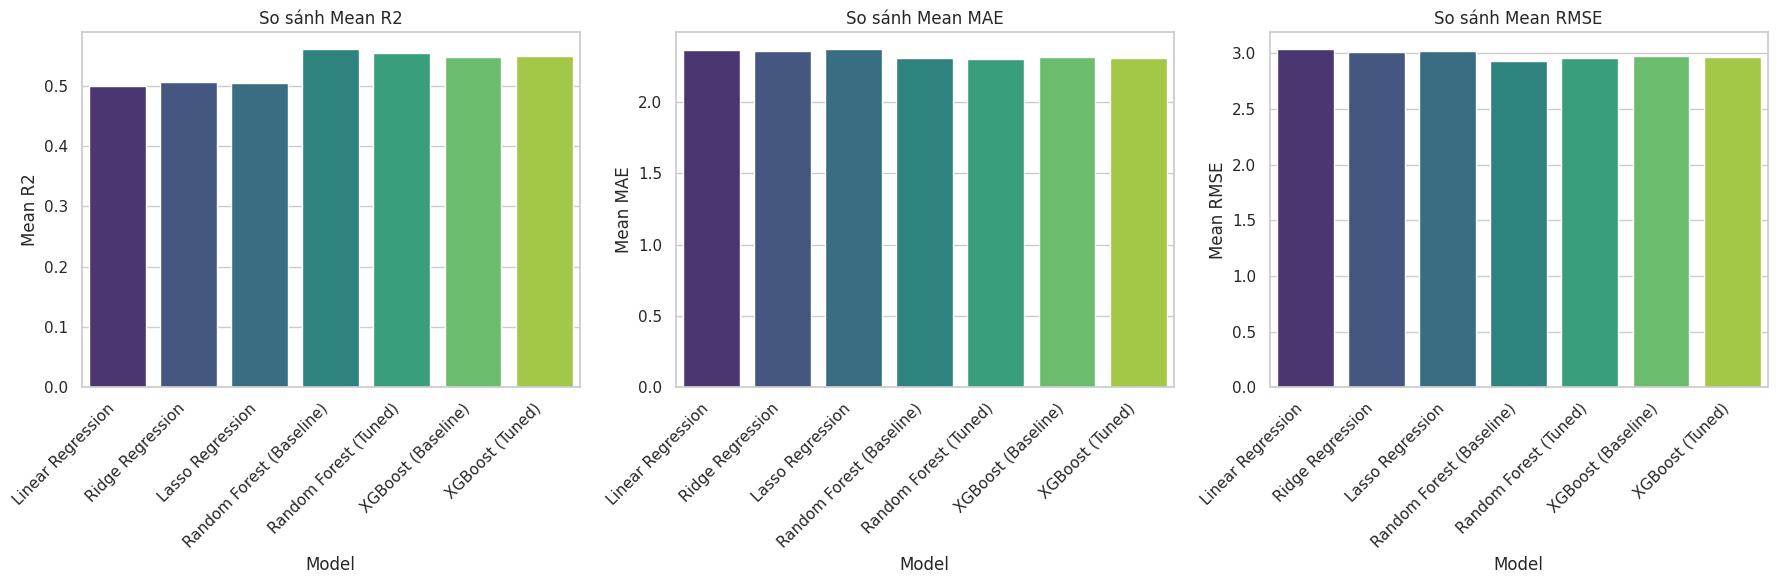

In [ ]:
# ---  So sánh độ chính xác của tất cả các mô hình ---

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Helper function to get results if missing
def get_model_metrics(model_var_name, X_test, y_test):
    if model_var_name in globals():
        model = globals()[model_var_name]
        y_pred = model.predict(X_test)
        return {
            'R2': r2_score(y_test, y_pred),
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
        }
    return {'R2': 0, 'MAE': 0, 'RMSE': 0}

# Ensure X_test and y_test are ready
if 'X_test' not in globals() or 'y_test' not in globals():
    X_test, y_test = X_test_int_rate_transformed, y_test_int_rate

# Fallback for baseline results
rf_res = rf_results if 'rf_results' in globals() else get_model_metrics('rf_model', X_test, y_test)
rf_t_res = rf_tuned_results if 'rf_tuned_results' in globals() else get_model_metrics('random_search_rf', X_test, y_test)
xgb_res = xgb_results if 'xgb_results' in globals() else get_model_metrics('xgb_model', X_test, y_test)
xgb_t_res = xgb_tuned_results if 'xgb_tuned_results' in globals() else get_model_metrics('random_search_xgb', X_test, y_test)

# Linear models metrics (from comparison_kfold_metrics or recalculate)
if 'comparison_kfold_metrics' not in globals():
    # Use metrics from the comparison_df if available as a fallback
    if 'comparison_df' in globals():
        lin_metrics = comparison_df.loc[['Linear Regression', 'Ridge (L2)', 'Lasso (L1)']].copy()
        lin_metrics.index = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
        lin_metrics.columns = ['Mean R2', 'Mean MAE', 'Mean RMSE']
        comparison_kfold_metrics = lin_metrics.reset_index().rename(columns={'index': 'Model'})

comparison_nonlinear_metrics = pd.DataFrame({
    'Model': [
        'Random Forest (Baseline)', 'Random Forest (Tuned)',
        'XGBoost (Baseline)', 'XGBoost (Tuned)'
    ],
    'Mean R2': [rf_res['R2'], rf_t_res['R2'], xgb_res['R2'], xgb_t_res['R2']],
    'Mean MAE': [rf_res['MAE'], rf_t_res['MAE'], xgb_res['MAE'], xgb_t_res['MAE']],
    'Mean RMSE': [rf_res['RMSE'], rf_t_res['RMSE'], xgb_res['RMSE'], xgb_t_res['RMSE']]
})

all_models_comparison = pd.concat([
    comparison_kfold_metrics.set_index('Model'),
    comparison_nonlinear_metrics.set_index('Model')
])

display(all_models_comparison)

# Plotting
metrics = ['Mean R2', 'Mean MAE', 'Mean RMSE']
plt.figure(figsize=(18, 6))
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)
    sns.barplot(x=all_models_comparison.index, y=all_models_comparison[metric], palette='viridis')
    plt.title(f'So sánh {metric}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Nhận xét:**

#### **1. Đánh giá các mô hình học máy phi tuyến tính (Random Forest & XGBoost)**

*   **Mục đích:** Các mô hình phi tuyến tính như Random Forest và XGBoost thường có khả năng nắm bắt các mối quan hệ phức tạp, phi tuyến tính và tương tác giữa các biến tốt hơn so với mô hình tuyến tính, điều này rất quan trọng trong dữ liệu tài chính.

*   **Kết quả Baseline:**
    *   **Random Forest:** R² = 0.5886, MAE = 2.0259, RMSE = 2.5856
    *   **XGBoost:** R² = 0.6064, MAE = 2.0002, RMSE = 2.5291

*   **Tối ưu hóa siêu tham số (Hyperparameter Tuning):**
    *   Sử dụng `RandomizedSearchCV` để tìm kiếm các tập siêu tham số tối ưu (`n_estimators`, `max_depth`, `min_samples_split`/`min_samples_leaf` cho RF; `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree` cho XGBoost).
    *   **Random Forest (Tuned):** R² = 0.7183, MAE = 1.6172, RMSE = 2.1553.
    *   **XGBoost (Tuned):** R² = R² = 0.8071, MAE = 1.3679, RMSE = 1.7834.
    

    **Nhận xét:** Việc tinh chỉnh siêu tham số đã giúp các mô hình phát huy tối đa sức mạnh. Cụ thể, XGBoost (Tuned) có thể giải thích được tới ~80.7% sự biến thiên của lãi suất, một con số cực kỳ lý tưởng đối với dữ liệu thực tế.

#### **2. Trích xuất và phân tích Độ quan trọng của đặc trưng (Feature Importance)**

*   Biểu đồ độ quan trọng của đặc trưng (Feature Importance) từ các mô hình phi tuyến cung cấp cái nhìn sâu sắc về những yếu tố ảnh hưởng mạnh nhất đến việc định giá lãi suất `int_rate`.
*   **Các đặc trưng quan trọng nhất thường là:** `term`, `total_bc_limit`, `num_tl_op_past_12m`, `verification_status_Verified`, `dti`, `mo_sin_old_rev_tl_op`, `percent_bc_gt_75`, `bc_util`, `annual_inc_log`, `loan_amnt_log`.
*   *Ý nghĩa tài chính:* `term` (kỳ hạn vay) và các biến liên quan đến lịch sử tín dụng/tài chính (`total_bc_limit`, `num_tl_op_past_12m`, `dti`, `bc_util`) là những yếu tố chính mà người cho vay sử dụng để đánh giá rủi ro và đặt lãi suất. Việc xác nhận thu nhập (`verification_status_Verified`) cũng có vai trò quan trọng. Các biến đổi Log của `annual_inc` và `loan_amnt` cũng xuất hiện, cho thấy mối quan hệ phi tuyến tính của chúng với lãi suất.

#### **3. So sánh độ chính xác, khả năng tổng quát hóa và mức độ giải thích giữa mô hình tuyến tính và phi tuyến**


| Model                      | Mean R2  | Mean MAE | Mean RMSE |
| :------------------------- | :------- | :------- | :-------- |
| Linear Regression          | 0.5576   | 2.1405   | 2.7154    |
| Ridge Regression           | 0.5576   | 2.1406   | 2.7153    |
| Lasso Regression           | 0.5104   | 2.2435   | 2.8554    |
| Random Forest (Tuned)      | 0.7183   | 1.6172   | 2.1553    |
| XGBoost (Tuned)            | **0.8071** | **1.3679** | **1.7834** |

*   **Độ chính xác và Khả năng tổng quát hóa:**

    * **Sự chênh lệch là rất rõ ràng:** Mô hình XGBoost (Tuned) áp đảo hoàn toàn cụm mô hình tuyến tính, đẩy R² từ mức ~0.55 lên **0.8071**, đồng thời giảm mạnh sai số trung bình (MAE) xuống chỉ còn **1.36%**.

    * Sự vượt trội này khẳng định rằng mối quan hệ trong bộ dữ liệu Lending Club có tính phi tuyến rất cao. Các mô hình Linear/Ridge/Lasso bị giới hạn bởi phương trình đường thẳng nên không thể học được các điểm rẽ nhánh của dữ liệu.

    * Việc kết hợp K-Fold Cross Validation cùng Hyperparameter Tuning đảm bảo rằng mức **R² ~ 80.7%** của XGBoost là kết quả của khả năng tổng quát hóa thực sự tốt trên dữ liệu chưa biết, không phải do hiện tượng học vẹt (Overfitting).

*   **Mức độ giải thích được:**
     * Mô hình tuyến tính (OLS, Ridge, Lasso) mang lại hệ số (Coefficients) rõ ràng cho từng biến, nhưng độ chính xác lại thấp do không xử lý được các quan hệ phức tạp.

    * Mô hình phi tuyến tính (Random Forest, XGBoost) hoạt động như một "hộp đen" (black-box) nhưng mang lại sức mạnh dự báo vượt bậc. Tuy nhiên, nhược điểm về khả năng diễn giải đã được nhóm khắc phục thành công nhờ việc trích xuất và phân tích `Feature Importance`.

# **PHẦN 2 – Phân tích cấu trúc thị trường chứng khoán Việt Nam bằng PCA từ rổ VN30**


---



## **Giới thiệu và Thu thập dữ liệu chứng khoán VN30**

### **Cấu trúc thị trường và Chỉ số VN30**
**VN30 là gì?**
VN30 là chỉ số giá chứng khoán đại diện cho 30 công ty niêm yết trên Sở Giao dịch Chứng khoán TP.HCM (HOSE) có giá trị vốn hóa thị trường và tính thanh khoản cao nhất. Danh mục này được định kỳ xem xét và điều chỉnh để đảm bảo luôn phản ánh đúng các doanh nghiệp đầu ngành.

**Vì sao chọn VN30 để đại diện cho thị trường khi phân tích PCA?**
Trong phân tích cấu trúc thị trường, việc lựa chọn tập dữ liệu đầu vào rất quan trọng:
1. **Tính đại diện cao:** Rổ VN30 thường chiếm khoảng 70-80% tổng giá trị vốn hóa và thanh khoản của toàn sàn HOSE. Do đó, xu hướng của VN30 phản ánh gần như chính xác nhịp đập của toàn thị trường chứng khoán Việt Nam.
2. **Loại bỏ nhiễu (Noise reduction):** Thị trường có hàng trăm mã cổ phiếu nhỏ (penny stocks) với thanh khoản thấp, dễ bị thao túng giá. Việc tập trung vào nhóm Blue-chips (VN30) giúp dữ liệu ổn định, minh bạch và làm tăng độ tin cậy khi trích xuất các thành phần chính bằng thuật toán học máy (PCA).
3. **Tính liên tục của dữ liệu:** 30 mã trong rổ VN30 đều có giao dịch sôi động hàng ngày, giảm thiểu tối đa các giá trị khuyết thiếu (missing values) do mất thanh khoản.

### **Phương pháp thu thập dữ liệu**
Để đảm bảo tính chính xác và sự ổn định tuyệt đối của dữ liệu, nhóm đã quyết định linh hoạt kết hợp hai phương pháp:
- **Đối với 30 mã cổ phiếu VN30:** Sử dụng thư viện `yfinance` kết nối trực tiếp với API công khai của Yahoo Finance để tự động tải về lịch sử giá đóng cửa (Close Price).
- **Đối với chỉ số tham chiếu VN30-Index:** Do các API tài chính trong nước thường có tường lửa chặn truy cập từ máy chủ đám mây (Google Colab), nhóm đã chủ động thu thập thủ công bằng cách tải trực tiếp file dữ liệu lịch sử (CSV) từ nền tảng **Investing.com**.

Việc kết hợp này vừa tận dụng được sức mạnh tự động hóa của API, vừa thể hiện khả năng xử lý tình huống linh hoạt để có được bộ dữ liệu Panel Data hoàn chỉnh nhất đưa vào mô hình.

## **2.1 Thu thập và tiền xử lý dữ liệu chứng khoán**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta


In [5]:
print("--- ĐANG THU THẬP DỮ LIỆU CHỨNG KHOÁN ---")

# Nguồn dữ liệu và Phương pháp thu thập:
# 1. Dữ liệu giá đóng cửa của 30 cổ phiếu VN30 được thu thập thông qua thư viện 'yfinance' (Yahoo Finance API).
# 2. Dữ liệu chỉ số VN30-Index được đọc từ file CSV 'VN30.csv.csv'.

# 1. Khai báo 30 mã cổ phiếu thuộc rổ VN30
vn30_tickers = [
    'ACB', 'BCM', 'BID', 'BVH', 'CTG', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG',
    'MBB', 'MSN', 'MWG', 'PLX', 'POW', 'SAB', 'SHB', 'SSB', 'SSI', 'STB',
    'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VRE'
]
tickers_yf = [ticker + '.VN' for ticker in vn30_tickers]

# Xác định mốc thời gian: 1 năm gần nhất (tính từ 30/04/2026 lùi lại)
start_str = '2025-04-30'
end_str = '2026-04-30'

print(f"Giai đoạn thu thập: {start_str} đến {end_str}")

# 2. Thu thập dữ liệu 30 mã VN30 từ Yahoo Finance API
print("\nĐang tải dữ liệu 30 mã cổ phiếu từ Yahoo Finance...")
panel_data = yf.download(tickers_yf, start=start_str, end=end_str, progress=False)['Close']
# Xóa hậu tố '.VN' trong tên cột
panel_data.columns = [col.replace('.VN', '') for col in panel_data.columns]
# Chuẩn hóa index về mốc ngày (bỏ giờ, phút)
panel_data.index = pd.to_datetime(panel_data.index).tz_localize(None).normalize()

# 3. Đọc dữ liệu VN30-Index từ file CSV
print("Đang đọc dữ liệu VN30-Index từ file VN30.csv.csv...")
vn30_index_data = pd.read_csv('VN30.csv.csv')

# Trích xuất 2 cột "Ngày" và "Lần cuối" (Giá đóng cửa), sau đó đổi tên
vn30_index_data = vn30_index_data[['Ngày', 'Lần cuối']]
vn30_index_data.columns = ['Date', 'VN30_INDEX']

# Loại bỏ dấu phẩy phân cách hàng nghìn và ép kiểu dữ liệu về số thực (float)
vn30_index_data['VN30_INDEX'] = vn30_index_data['VN30_INDEX'].str.replace(',', '').astype(float)

# Chuyển cột Date sang định dạng datetime chuẩn (theo định dạng dd/mm/yyyy của file) và đưa làm Index
vn30_index_data['Date'] = pd.to_datetime(vn30_index_data['Date'], format='%d/%m/%Y')
vn30_index_data.set_index('Date', inplace=True)
vn30_index_data.index = vn30_index_data.index.tz_localize(None).normalize()

print("-> Đã đọc và xử lý file CSV thành công!")

# 4. Merge (Gộp) thành bảng Panel Data chung
df_final = panel_data.join(vn30_index_data, how='outer')

# 5. Lọc đúng giới hạn 1 năm và Xử lý Missing Values
df_final = df_final.loc[start_str:end_str]
missing_before = df_final.isnull().sum().sum()
# Phương pháp Forward Fill lấp đầy giá trị trống bằng giá của ngày giao dịch gần nhất
df_final = df_final.ffill().bfill()
missing_after = df_final.isnull().sum().sum()

print(f"\n--- HOÀN TẤT XỬ LÝ DỮ LIỆU ---")
print(f"Tổng số giá trị thiếu ban đầu: {missing_before}")
print(f"Tổng số giá trị thiếu sau xử lý (ffill): {missing_after}")

print(f"\nKích thước tập dữ liệu Panel Data: {df_final.shape}")
print("5 dòng dữ liệu đầu tiên:")
display(df_final.head())

--- ĐANG THU THẬP DỮ LIỆU CHỨNG KHOÁN ---
Giai đoạn thu thập: 2025-04-30 đến 2026-04-30

Đang tải dữ liệu 30 mã cổ phiếu từ Yahoo Finance...


/tmp/ipykernel_28530/1553018640.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  panel_data = yf.download(tickers_yf, start=start_str, end=end_str, progress=False)['Close']


Đang đọc dữ liệu VN30-Index từ file VN30.csv.csv...
-> Đã đọc và xử lý file CSV thành công!

--- HOÀN TẤT XỬ LÝ DỮ LIỆU ---
Tổng số giá trị thiếu ban đầu: 0
Tổng số giá trị thiếu sau xử lý (ffill): 0

Kích thước tập dữ liệu Panel Data: (248, 31)
5 dòng dữ liệu đầu tiên:


,ACB,BCM,BID,BVH,CTG,FPT,GAS,GVR,HDB,HPG,...,TPB,VCB,VHM,VIB,VIC,VJC,VNM,VPB,VRE,VN30_INDEX
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-05,19971.751953,56520.898438,34466.566406,45231.425781,25522.599609,92550.601562,55013.097656,24500.615234,16346.672852,21416.666016,...,12030.347656,56686.230469,60900.0,14596.163086,35000.0,89600.0,52492.109375,16160.846680,24900.0,1320.41
2025-05-06,19930.230469,55046.441406,34565.464844,46605.046875,25693.433594,93488.039062,56047.531250,23958.347656,16385.226562,21208.333984,...,12207.264648,56586.957031,60900.0,14554.578125,35250.0,89000.0,52492.109375,16452.910156,24900.0,1319.66
2025-05-07,19930.230469,56127.710938,34516.015625,48076.785156,25590.931641,93488.039062,56893.886719,24500.615234,16153.905273,21166.666016,...,12295.722656,56586.957031,62000.0,14512.993164,36700.0,88900.0,52768.867188,16550.263672,24900.0,1324.80
2025-05-08,20054.794922,58978.328125,35059.964844,47978.671875,25659.265625,97408.226562,57740.242188,26176.712891,16385.226562,21416.666016,...,12428.410156,56686.230469,62200.0,14637.747070,39250.0,89800.0,52953.375000,16550.263672,25000.0,1351.10
2025-05-09,20054.794922,58486.843750,34713.816406,47291.859375,25590.931641,98856.992188,57458.121094,26275.306641,16346.672852,21375.000000,...,12428.410156,56189.855469,62200.0,14596.163086,38250.0,89500.0,53230.132812,16550.263672,25000.0,1352.25


## **Tỷ suất sinh lợi hằng ngày**

In [9]:
print("Đang tính toán tỷ suất sinh lợi hằng ngày...")
df_returns = df_final.pct_change().dropna()

print("-> Đã tính toán tỷ suất sinh lợi hằng ngày thành công!")
print(f"Kích thước tập dữ liệu Daily Returns: {df_returns.shape}")
print("5 dòng dữ liệu Daily Returns đầu tiên:")
display(df_returns.head())


# Display descriptive statistics of stock returns
print("\nDescriptive Statistics of Stock Returns:")
display(stock_returns_only.describe())

# Check for any remaining missing values in stock returns
print("\nMissing values in Stock Returns:")
print(stock_returns_only.isnull().sum()[stock_returns_only.isnull().sum() > 0])

# Standardize stock returns (mean-centering)
mean_returns = stock_returns_only.mean()
standardized_returns = stock_returns_only - mean_returns

print("\nShape of standardized_returns:", standardized_returns.shape)

Đang tính toán tỷ suất sinh lợi hằng ngày...
-> Đã tính toán tỷ suất sinh lợi hằng ngày thành công!
Kích thước tập dữ liệu Daily Returns: (247, 31)
5 dòng dữ liệu Daily Returns đầu tiên:


,ACB,BCM,BID,BVH,CTG,FPT,GAS,GVR,HDB,HPG,...,TPB,VCB,VHM,VIB,VIC,VJC,VNM,VPB,VRE,VN30_INDEX
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-06,-0.002079,-0.026087,0.002869,0.030369,0.006693,0.010129,0.018803,-0.022133,0.002359,-0.009728,...,0.014706,-0.001751,0.000000,-0.002849,0.007143,-0.006696,0.000000,0.018072,0.000000,-0.000568
2025-05-07,0.000000,0.019643,-0.001431,0.031579,-0.003989,0.000000,0.015101,0.022634,-0.014118,-0.001965,...,0.007246,0.000000,0.018062,-0.002857,0.041135,-0.001124,0.005272,0.005917,0.000000,0.003895
2025-05-08,0.006250,0.050788,0.015759,-0.002041,0.002670,0.041933,0.014876,0.068410,0.014320,0.011811,...,0.010791,0.001754,0.003226,0.008596,0.069482,0.010124,0.003497,0.000000,0.004016,0.019852
2025-05-09,0.000000,-0.008333,-0.009873,-0.014315,-0.002663,0.014873,-0.004886,0.003766,-0.002353,-0.001945,...,0.000000,-0.008757,0.000000,-0.002841,-0.025478,-0.003341,0.005226,0.000000,0.000000,0.000851
2025-05-12,0.010352,0.033613,0.004273,0.012448,0.010681,0.019828,0.019640,0.048781,0.014151,-0.009747,...,0.049822,0.000000,0.001608,0.025641,0.037908,0.010056,0.015598,0.020588,0.020000,0.014635



Descriptive Statistics of Stock Returns:


,ACB,BCM,BID,BVH,CTG,FPT,GAS,GVR,HDB,HPG,...,TCB,TPB,VCB,VHM,VIB,VIC,VJC,VNM,VPB,VRE
count,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,...,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000
mean,0.000786,-0.000028,0.000825,0.002147,0.001440,-0.000626,0.001624,0.001726,0.002225,0.001216,...,0.001311,0.001460,0.000372,0.004119,0.000606,0.007946,0.003201,0.000773,0.002340,0.001516
std,0.015999,0.020893,0.020634,0.026569,0.018330,0.019979,0.026847,0.029585,0.022542,0.018316,...,0.020704,0.022073,0.017732,0.033960,0.017874,0.034443,0.027572,0.018567,0.026039,0.030479
min,-0.068670,-0.069966,-0.069725,-0.069191,-0.068724,-0.069853,-0.069990,-0.069954,-0.069498,-0.069725,...,-0.069952,-0.069909,-0.069805,-0.070000,-0.069915,-0.070000,-0.068504,-0.068910,-0.069858,-0.069588
25%,-0.005976,-0.011189,-0.007979,-0.014443,-0.007844,-0.013375,-0.010213,-0.015066,-0.009011,-0.008742,...,-0.010581,-0.011321,-0.008347,-0.014801,-0.008561,-0.010380,-0.013489,-0.009219,-0.012975,-0.016530
50%,0.000000,0.000000,0.000000,0.000000,0.001193,-0.002130,0.000000,0.001416,0.001585,0.000000,...,0.001429,0.000000,0.000000,0.001927,0.000000,0.003738,0.000000,0.000000,0.000000,0.000000
75%,0.007984,0.011354,0.009985,0.013342,0.010471,0.010174,0.012967,0.019466,0.012556,0.010718,...,0.011197,0.011545,0.006335,0.020234,0.008572,0.030984,0.013782,0.009585,0.015888,0.017659
max,0.069388,0.069971,0.069686,0.069808,0.066754,0.069036,0.069882,0.070000,0.070000,0.069034,...,0.069686,0.068681,0.069659,0.070000,0.068493,0.070000,0.069872,0.069510,0.069915,0.070000



Missing values in Stock Returns:
Series([], dtype: int64)

Shape of standardized_returns: (247, 30)



### **Vì sao dùng Tỷ suất sinh lợi (Return) thay vì Giá đóng cửa (Close Price)?**
Khi áp dụng thuật toán PCA, việc sử dụng Tỷ suất sinh lợi (Daily Return) thay vì Giá đóng cửa tuyệt đối là bắt buộc vì 2 lý do cốt lõi:
1. **Khắc phục chênh lệch quy mô (Scale):** Mức giá của các cổ phiếu trong VN30 rất khác nhau (Ví dụ: FPT > 100k, trong khi VRE chỉ ~20k). Nếu dùng giá đóng cửa, mô hình PCA sẽ bị sai lệch và thiên vị các cổ phiếu có thị giá lớn. Return giúp đưa tất cả về cùng một hệ quy chiếu là phần trăm (%), giúp việc so sánh công bằng hơn.
2. **Đảm bảo tính dừng (Stationarity):** Chuỗi thời gian của giá cổ phiếu mang tính xu hướng (trend) dài hạn và không dừng (non-stationary). Bằng cách tính Return, ta loại bỏ được xu hướng này, biến dữ liệu thành chuỗi dừng tập trung vào biến động cốt lõi hàng ngày, thỏa mãn giả định của các mô hình định lượng.

### **Ý nghĩa của Ma trận tương quan (Correlation Matrix)**
- **Khái niệm:** Ma trận tương quan đo lường mức độ di chuyển cùng chiều hay ngược chiều giữa các cặp cổ phiếu (giá trị chạy từ -1 đến 1).
- **Ý nghĩa trong PCA:** Trong rổ VN30, các cổ phiếu thường có hệ số tương quan dương khá cao với nhau do chúng cùng chịu tác động từ rủi ro hệ thống (Macro/Market Risk). Tính chất tương quan chặt chẽ này chính là **tiền đề quan trọng nhất** để thuật toán PCA có thể gom nhóm và trích xuất ra một "Thành phần chính" (Principal Component 1) giải thích được phần lớn sự biến động chung của toàn thị trường.

In [11]:
print("### Thông tin chung về DataFrame df_final ###")
df_final.info()

print("\n### Thống kê mô tả cho df_final ###")
display(df_final.describe())

print("\n### Kiểm tra lại giá trị thiếu trong df_final ###")
missing_values_df_final = df_final.isnull().sum()
print(missing_values_df_final[missing_values_df_final > 0])

print("\n### Thống kê mô tả cho df_returns (Tỷ suất sinh lợi) ###")
display(df_returns.describe())

print("\n### Kiểm tra lại giá trị thiếu trong df_returns ###")
missing_values_df_returns = df_returns.isnull().sum()
print(missing_values_df_returns[missing_values_df_returns > 0])

print("\n### Ma trận tương quan của tỷ suất sinh lợi (df_returns) ###")
correlation_matrix = df_returns.corr()
display(correlation_matrix.head()) # Hiển thị 5 dòng đầu của ma trận tương quan để xem trước

### Thông tin chung về DataFrame df_final ###
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2025-05-05 to 2026-04-29
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ACB         248 non-null    float64
 1   BCM         248 non-null    float64
 2   BID         248 non-null    float64
 3   BVH         248 non-null    float64
 4   CTG         248 non-null    float64
 5   FPT         248 non-null    float64
 6   GAS         248 non-null    float64
 7   GVR         248 non-null    float64
 8   HDB         248 non-null    float64
 9   HPG         248 non-null    float64
 10  MBB         248 non-null    float64
 11  MSN         248 non-null    float64
 12  MWG         248 non-null    float64
 13  PLX         248 non-null    float64
 14  POW         248 non-null    float64
 15  SAB         248 non-null    float64
 16  SHB         248 non-null    float64
 17  SSB         248 non-null    float64
 18  SSI  

,ACB,BCM,BID,BVH,CTG,FPT,GAS,GVR,HDB,HPG,...,TPB,VCB,VHM,VIB,VIC,VJC,VNM,VPB,VRE,VN30_INDEX
count,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,...,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000
mean,23916.123244,63163.692635,40105.111029,59667.694241,33517.601759,95775.743731,72803.097058,30400.520083,23430.482804,26238.306436,...,16312.661920,60965.752063,99713.709677,17066.854516,103897.983871,148859.677419,60027.159400,26496.521370,29831.451613,1802.744113
std,1842.456800,5334.780861,4643.928409,11365.966140,3757.876173,9634.885587,17707.106922,4213.463255,3858.890889,2302.006069,...,2110.325679,4279.037069,19425.699138,1667.323072,48389.632300,39282.368060,4802.165616,4893.156695,3931.258865,215.687355
min,19930.230469,50500.000000,34466.566406,45231.425781,25522.599609,73100.000000,55013.097656,23958.347656,16153.905273,21166.666016,...,12030.347656,55296.375000,58000.000000,14512.993164,35000.000000,87000.000000,52153.300781,16160.846680,24050.000000,1319.660000
25%,23000.000000,59543.539062,37175.000000,51216.496094,31194.287109,93488.039062,61600.000000,27606.326172,21165.856934,25950.000000,...,14952.380859,57675.000000,92000.000000,15928.114502,57750.000000,120650.000000,57308.490234,24612.500000,26500.000000,1655.290000
50%,23950.000000,64777.863281,39050.000000,54450.000000,34361.171875,98673.226562,64000.000000,29060.587891,24385.072266,26750.000000,...,16900.000000,59850.000000,99900.000000,16687.031250,102375.000000,156200.000000,60040.683594,27775.000000,29500.000000,1864.805000
75%,25012.500000,66670.083984,40674.174805,70850.000000,35300.000000,101753.001953,79225.000000,32153.974609,25912.500000,27712.500000,...,17600.000000,63025.000000,107700.000000,17789.228516,145150.000000,179025.000000,62100.000000,29500.000000,32000.000000,1959.912500
max,29450.000000,78637.773438,55000.000000,86000.000000,41500.000000,110945.515625,128700.000000,45750.000000,29700.000000,30350.000000,...,21000.000000,76000.000000,151000.000000,22375.792969,225500.000000,219100.000000,73400.000000,38650.000000,43400.000000,2096.760000



### Kiểm tra lại giá trị thiếu trong df_final ###
Series([], dtype: int64)

### Thống kê mô tả cho df_returns (Tỷ suất sinh lợi) ###


,ACB,BCM,BID,BVH,CTG,FPT,GAS,GVR,HDB,HPG,...,TPB,VCB,VHM,VIB,VIC,VJC,VNM,VPB,VRE,VN30_INDEX
count,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,...,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000
mean,0.000786,-0.000028,0.000825,0.002147,0.001440,-0.000626,0.001624,0.001726,0.002225,0.001216,...,0.001460,0.000372,0.004119,0.000606,0.007946,0.003201,0.000773,0.002340,0.001516,0.001826
std,0.015999,0.020893,0.020634,0.026569,0.018330,0.019979,0.026847,0.029585,0.022542,0.018316,...,0.022073,0.017732,0.033960,0.017874,0.034443,0.027572,0.018567,0.026039,0.030479,0.013942
min,-0.068670,-0.069966,-0.069725,-0.069191,-0.068724,-0.069853,-0.069990,-0.069954,-0.069498,-0.069725,...,-0.069909,-0.069805,-0.070000,-0.069915,-0.070000,-0.068504,-0.068910,-0.069858,-0.069588,-0.064846
25%,-0.005976,-0.011189,-0.007979,-0.014443,-0.007844,-0.013375,-0.010213,-0.015066,-0.009011,-0.008742,...,-0.011321,-0.008347,-0.014801,-0.008561,-0.010380,-0.013489,-0.009219,-0.012975,-0.016530,-0.004524
50%,0.000000,0.000000,0.000000,0.000000,0.001193,-0.002130,0.000000,0.001416,0.001585,0.000000,...,0.000000,0.000000,0.001927,0.000000,0.003738,0.000000,0.000000,0.000000,0.000000,0.001966
75%,0.007984,0.011354,0.009985,0.013342,0.010471,0.010174,0.012967,0.019466,0.012556,0.010718,...,0.011545,0.006335,0.020234,0.008572,0.030984,0.013782,0.009585,0.015888,0.017659,0.009704
max,0.069388,0.069971,0.069686,0.069808,0.066754,0.069036,0.069882,0.070000,0.070000,0.069034,...,0.068681,0.069659,0.070000,0.068493,0.070000,0.069872,0.069510,0.069915,0.070000,0.048915



### Kiểm tra lại giá trị thiếu trong df_returns ###
Series([], dtype: int64)

### Ma trận tương quan của tỷ suất sinh lợi (df_returns) ###


,ACB,BCM,BID,BVH,CTG,FPT,GAS,GVR,HDB,HPG,...,TPB,VCB,VHM,VIB,VIC,VJC,VNM,VPB,VRE,VN30_INDEX
ACB,1.000000,0.339877,0.465683,0.377842,0.608193,0.430154,0.048981,0.269622,0.614058,0.567140,...,0.695485,0.499159,0.251414,0.658860,0.113689,0.230978,0.343580,0.683063,0.285773,0.698250
BCM,0.339877,1.000000,0.355700,0.431779,0.425802,0.321104,0.220520,0.541635,0.294999,0.317475,...,0.388618,0.311076,0.200169,0.342641,0.139861,0.117824,0.394548,0.315805,0.172830,0.448671
BID,0.465683,0.355700,1.000000,0.280230,0.651917,0.403504,0.320368,0.383220,0.315592,0.393939,...,0.524838,0.783450,0.116621,0.466808,0.040621,0.151876,0.415303,0.464714,0.127431,0.511649
BVH,0.377842,0.431779,0.280230,1.000000,0.354971,0.305704,0.278847,0.426986,0.284849,0.361079,...,0.385109,0.296445,0.198281,0.309775,0.079789,0.111841,0.291542,0.307415,0.187206,0.424975
CTG,0.608193,0.425802,0.651917,0.354971,1.000000,0.382975,0.192943,0.327817,0.489061,0.475398,...,0.606071,0.602828,0.287240,0.591190,0.166224,0.142622,0.356490,0.591142,0.290171,0.670573


**a. Phân phối lợi suất hàng ngày**

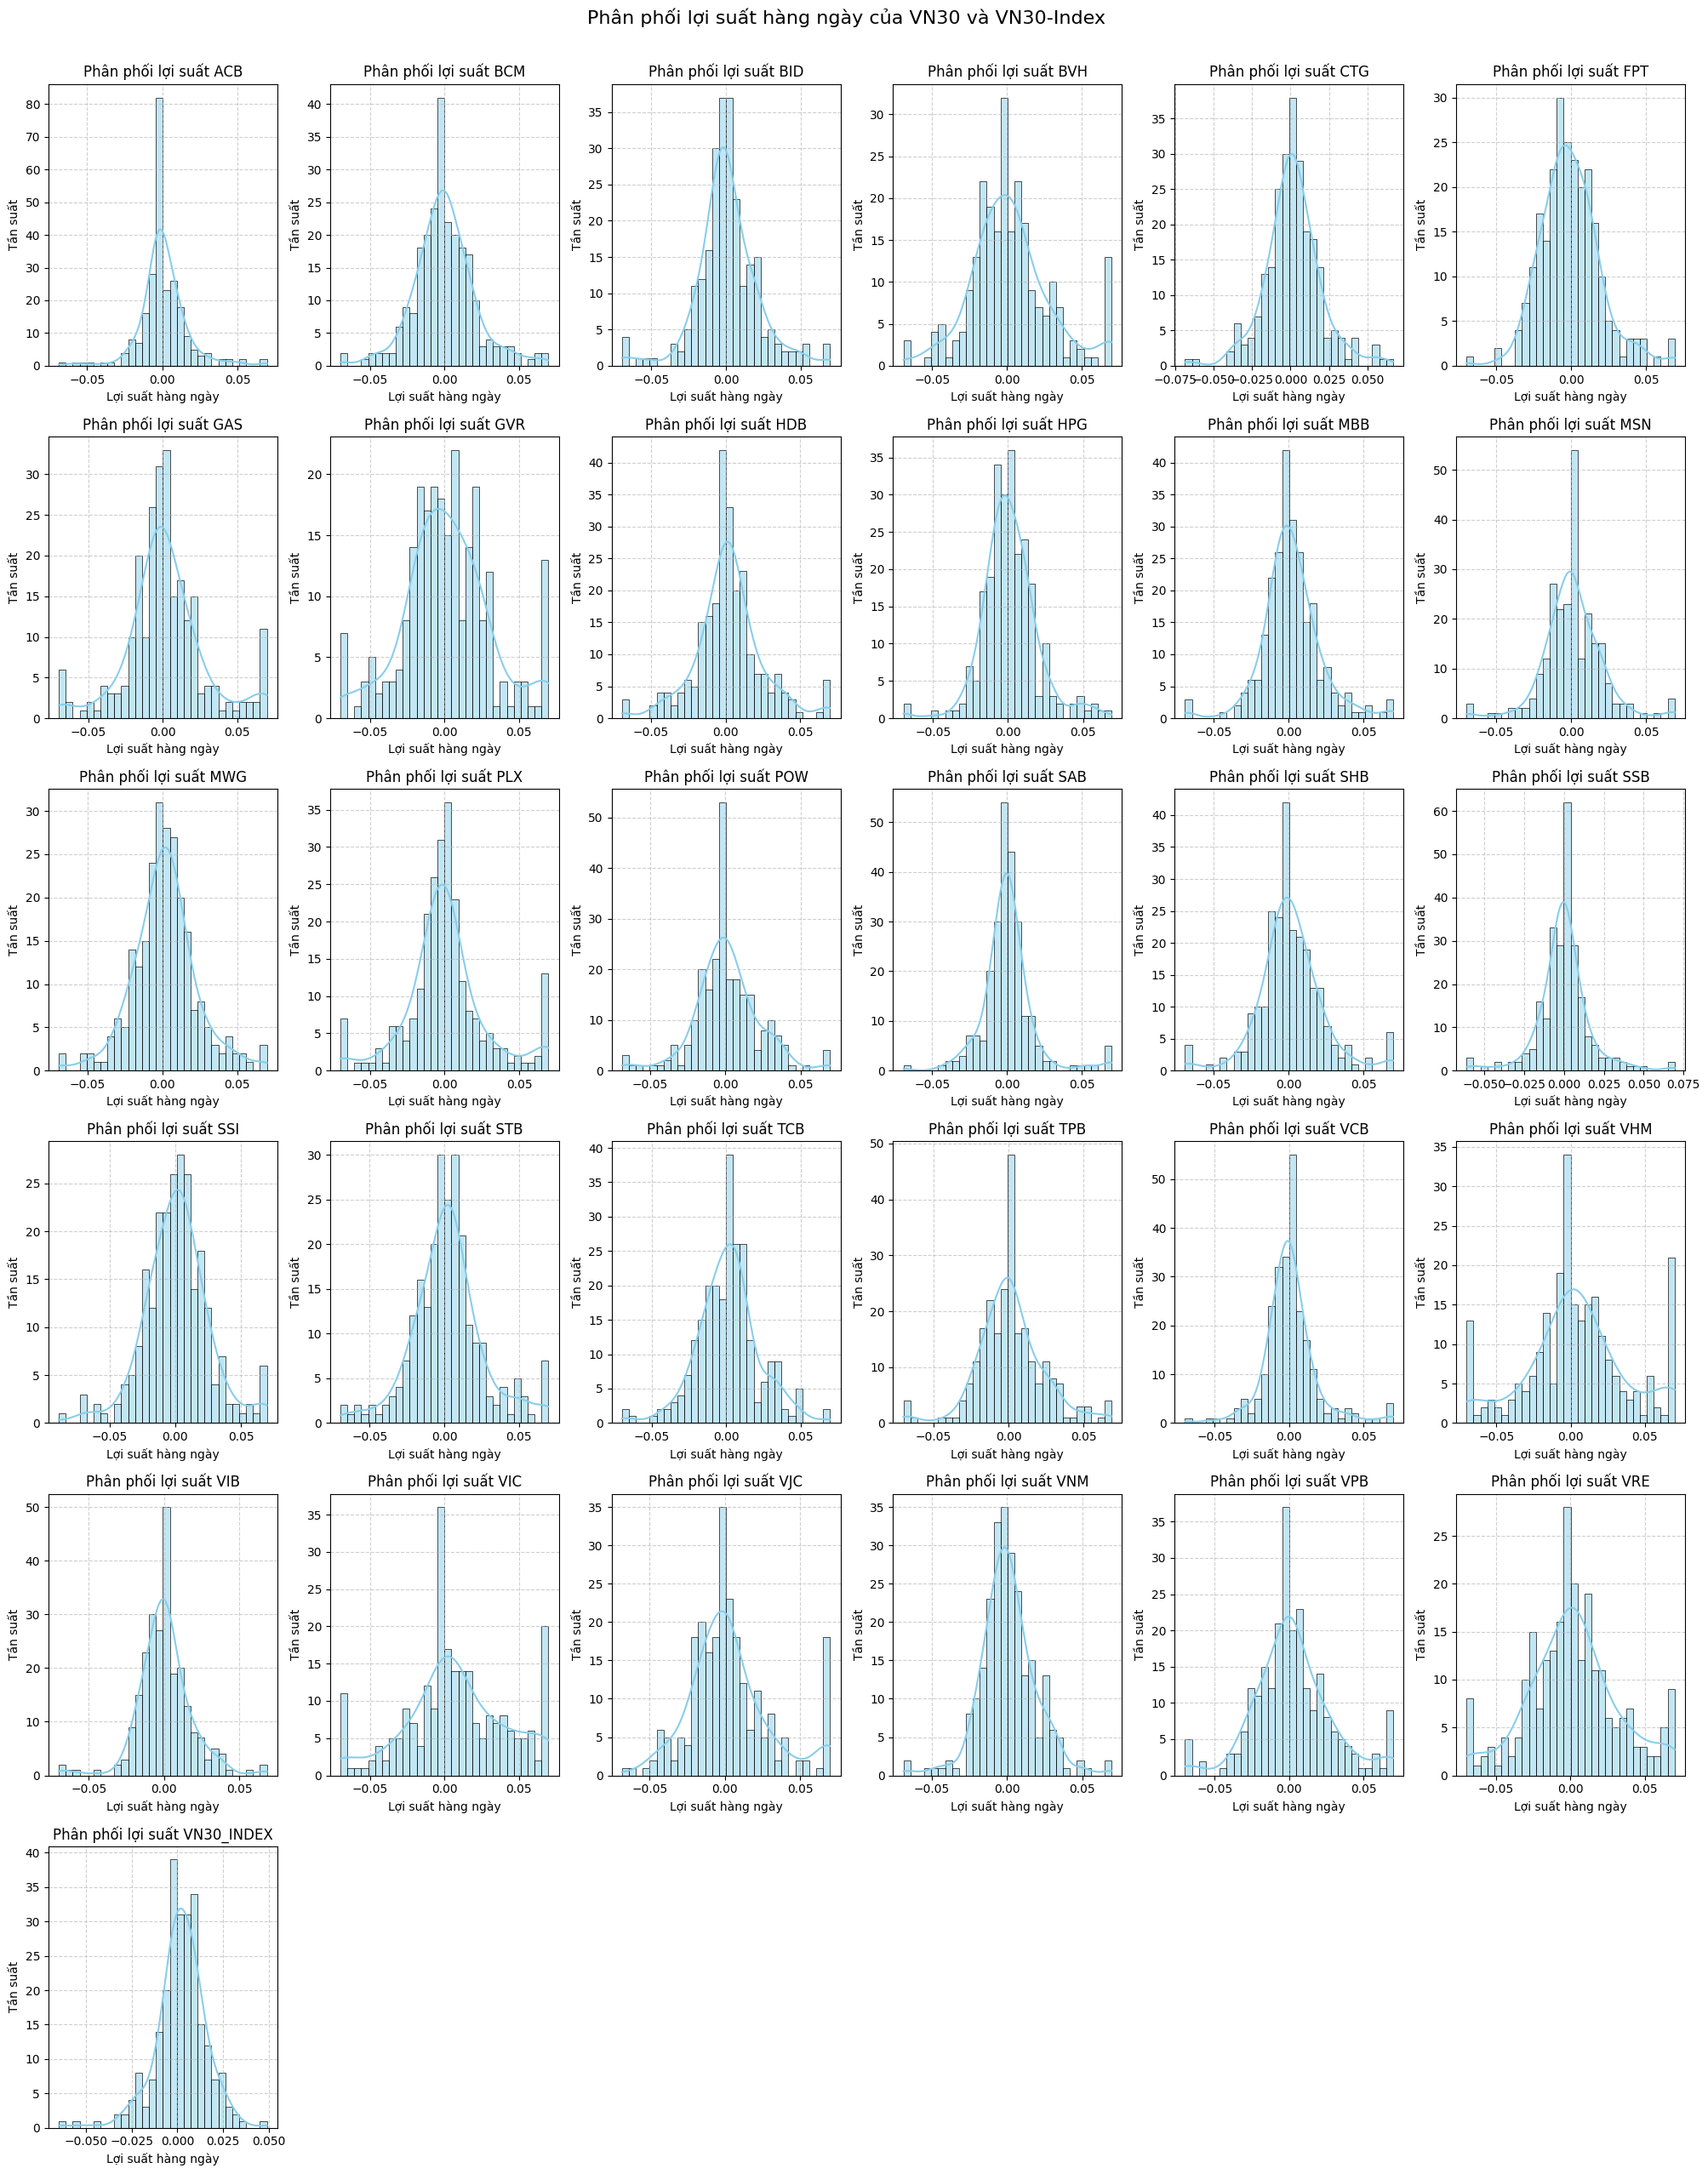

In [13]:
# Thiết lập kích thước đồ thị
plt.figure(figsize=(20, 25))

# Lặp qua từng cột (từng mã cổ phiếu/chỉ số) trong df_returns để vẽ biểu đồ phân phối
for i, column in enumerate(df_returns.columns):
    plt.subplot(6, 6, i + 1) # Tạo subplot (6 hàng, 6 cột)
    sns.histplot(df_returns[column], kde=True, bins=30, color='skyblue')
    plt.title(f'Phân phối lợi suất {column}')
    plt.xlabel('Lợi suất hàng ngày')
    plt.ylabel('Tần suất')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Điều chỉnh layout để tránh chồng chéo tiêu đề
plt.suptitle('Phân phối lợi suất hàng ngày của VN30 và VN30-Index', y=1.02, fontsize=16)
plt.show()

**b. Ma trận tương quan của lợi suất**

### 3.2. Ma trận tương quan của lợi suất chuẩn hóa ###


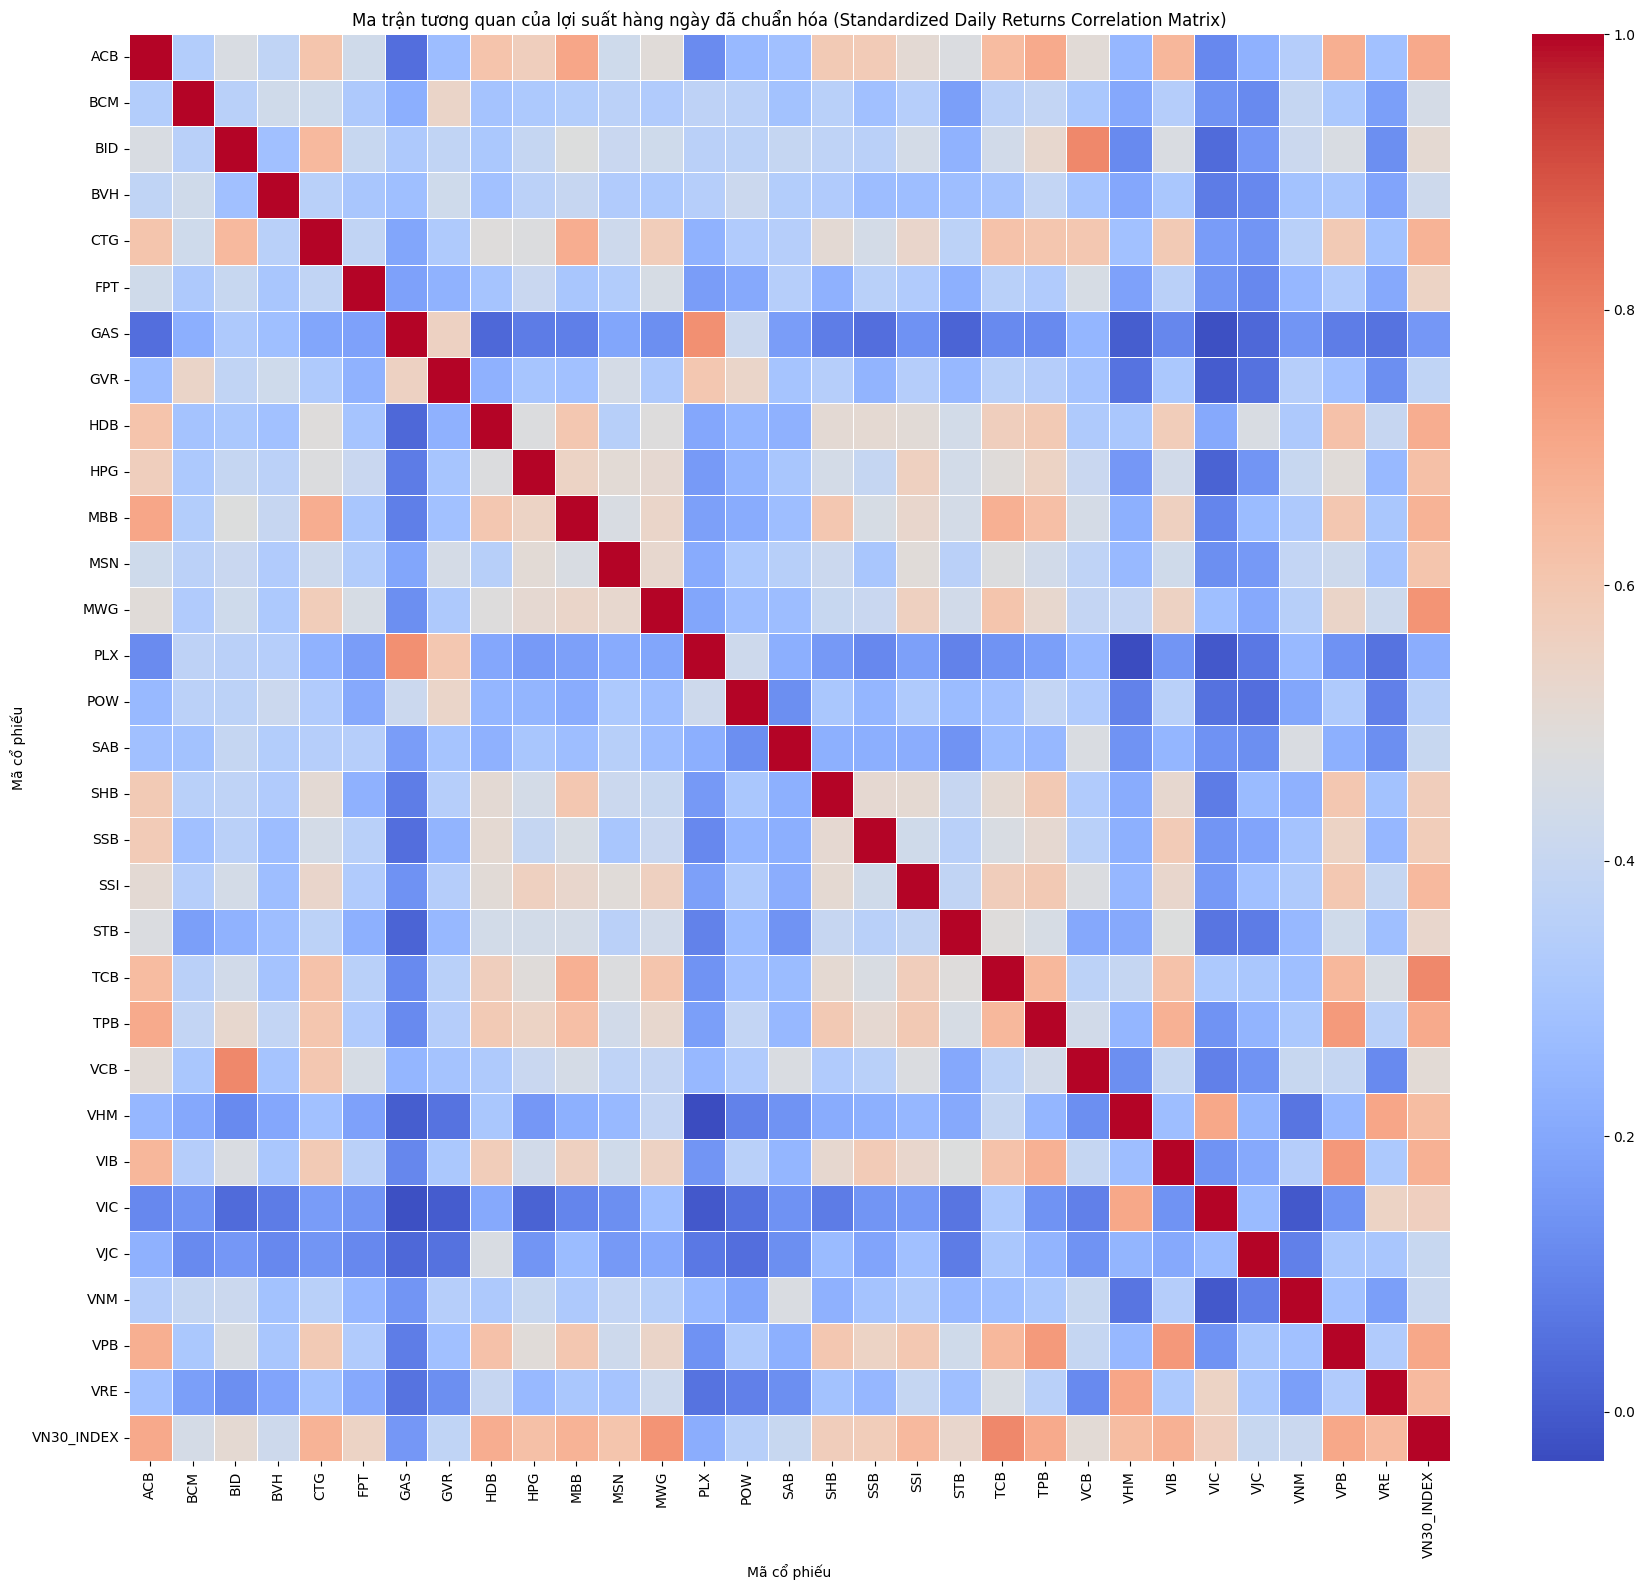


Ma trận tương quan (5x5 đầu tiên) của lợi suất chuẩn hóa:


,ACB,BCM,BID,BVH,CTG
ACB,1.000000,0.339877,0.465683,0.377842,0.608193
BCM,0.339877,1.000000,0.355700,0.431779,0.425802
BID,0.465683,0.355700,1.000000,0.280230,0.651917
BVH,0.377842,0.431779,0.280230,1.000000,0.354971
CTG,0.608193,0.425802,0.651917,0.354971,1.000000


In [14]:
print("### 3.2. Ma trận tương quan của lợi suất chuẩn hóa ###")

# Chuẩn hóa lợi suất bằng StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standardized_returns = pd.DataFrame(scaler.fit_transform(df_returns), columns=df_returns.columns, index=df_returns.index)

# Tính toán ma trận tương quan của lợi suất chuẩn hóa
correlation_matrix_standardized = standardized_returns.corr()

# Trực quan hóa ma trận tương quan bằng heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(correlation_matrix_standardized, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Ma trận tương quan của lợi suất hàng ngày đã chuẩn hóa (Standardized Daily Returns Correlation Matrix)')
plt.xlabel('Mã cổ phiếu')
plt.ylabel('Mã cổ phiếu')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nMa trận tương quan (5x5 đầu tiên) của lợi suất chuẩn hóa:")
display(correlation_matrix_standardized.iloc[:5, :5])

## **2.3 Xây dựng thuật toán PCA**

### **a. Tính toán ma trận hiệp phương sai (Covariance Matrix)**


In [15]:
# Calculate the covariance matrix
cov_matrix = standardized_returns.cov()

print("Shape of covariance matrix:", cov_matrix.shape)
print("\nCovariance Matrix (first 5x5):")
display(cov_matrix.iloc[:5, :5])

Shape of covariance matrix: (31, 31)

Covariance Matrix (first 5x5):


,ACB,BCM,BID,BVH,CTG
ACB,1.004065,0.341258,0.467576,0.379378,0.610665
BCM,0.341258,1.004065,0.357146,0.433534,0.427533
BID,0.467576,0.357146,1.004065,0.281369,0.654567
BVH,0.379378,0.433534,0.281369,1.004065,0.356414
CTG,0.610665,0.427533,0.654567,0.356414,1.004065


### **b. Tính toán trị riêng (Eigenvalues) và vector riêng (Eigenvectors)**

In [33]:
# Ensure standardized_stock_returns is defined and correctly structured
# This block is added for robustness in case previous cells were not run
if 'standardized_stock_returns' not in globals():
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    # Assuming df_returns is defined from previous cells
    # standardized_returns includes VN30_INDEX
    temp_standardized_returns = pd.DataFrame(scaler.fit_transform(df_returns), columns=df_returns.columns, index=df_returns.index)
    # standardized_stock_returns EXCLUDES VN30_INDEX
    standardized_stock_returns = temp_standardized_returns.drop(columns=['VN30_INDEX'], errors='ignore')

X = standardized_stock_returns.values # Lấy giá trị numpy array từ DataFrame đã chuẩn hóa chỉ chứa cổ phiếu

print(f"Kích thước dữ liệu đầu vào cho PCA: {X.shape}")
print(f"Giá trị trung bình của cột đầu tiên sau chuẩn hóa (kiểm tra): {np.mean(X[:,0]):.4f}")

cov_matrix = np.cov(X, rowvar=False) # rowvar=False vì mỗi hàng là một quan sát, mỗi cột là một biến

print(f"\nKích thước ma trận hiệp phương sai: {cov_matrix.shape}")

# Tính trị riêng (eigenvalues) và vector riêng (eigenvectors) từ ma trận hiệp phương sai.
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nĐã tính toán trị riêng và vector riêng.")

Kích thước dữ liệu đầu vào cho PCA: (247, 30)
Giá trị trung bình của cột đầu tiên sau chuẩn hóa (kiểm tra): -0.0000

Kích thước ma trận hiệp phương sai: (30, 30)

Đã tính toán trị riêng và vector riêng.


**Giải thích ý nghĩa của các vector riêng trong PCA**

**1. Hướng của Phương sai tối đa:** Mỗi vector riêng đại diện cho một hướng trong không gian dữ liệu mà dọc theo đó dữ liệu có phương sai lớn nhất. Hay nói cách khác, chúng chỉ ra các hướng mà dữ liệu 'trải rộng' nhiều nhất.

**2. Độc lập và Trực giao:** Các vector riêng này là trực giao (vuông góc) với nhau, có nghĩa là mỗi thành phần chính nắm bắt một khía cạnh biến động độc lập của dữ liệu.

**3. Tầm quan trọng:** Vector riêng tương ứng với trị riêng (eigenvalue) càng lớn thì nó càng giải thích được nhiều phương sai của dữ liệu. Do đó, vector riêng có trị riêng lớn nhất chính là PC1 (thành phần chính đầu tiên), vector có trị riêng lớn thứ hai là PC2, và cứ thế tiếp tục.

**4. Hệ số tải (Loadings):** Các giá trị thành phần trong mỗi vector riêng (còn gọi là 'loadings') cho biết mức độ đóng góp của từng biến gốc (ví dụ: từng mã cổ phiếu trong trường hợp này) vào thành phần chính đó. Một loading lớn (dương hoặc âm) cho thấy biến gốc đó có ảnh hưởng mạnh đến hướng và biến động của thành phần chính.

### **c. Sắp xếp các thành phần chính**

In [34]:
idx = np.argsort(eigenvalues)[::-1] # Lấy chỉ số để sắp xếp giảm dần
sorted_eigenvalues = eigenvalues[idx]
sorted_eigenvectors = eigenvectors[:, idx]

print("\nTrị riêng (Eigenvalues) đã sắp xếp:")
print(sorted_eigenvalues)

print("\nVector riêng (Eigenvectors) đã sắp xếp (5 hàng đầu tiên của PC1):")
print(sorted_eigenvectors[:5, :5]) # In 5 hàng đầu của 5 PC đầu tiên

# Tính toán tỷ lệ phương sai giải thích được (Explained Variance Ratio)
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)

print("\nExplained Variance Ratio của từng thành phần chính:")
print(explained_variance_ratio)
print(f"\nTổng phương sai được giải thích bởi 2 PC đầu tiên: {explained_variance_ratio[:2].sum()*100:.2f}%")

print("\n--- HOÀN TẤT XÂY DỰNG PCA ---")

# Tạo PC1 (chuỗi thời gian của PC1 scores)
pc1_vector_scratch = sorted_eigenvectors[:, 0] # PC1 là vector riêng đầu tiên

# Chuyển đổi dữ liệu gốc X lên không gian PC1
pc1_scores_scratch = X.dot(pc1_vector_scratch)

# Ensure standardized_stock_returns is defined (for robustness)
if 'standardized_stock_returns' not in globals():
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    # Assuming df_returns is defined from previous cells
    temp_standardized_returns = pd.DataFrame(scaler.fit_transform(df_returns), columns=df_returns.columns, index=df_returns.index)
    standardized_stock_returns = temp_standardized_returns.drop(columns=['VN30_INDEX'], errors='ignore')

# Tạo DataFrame cho PC1 scores để dễ dàng sử dụng cho các bước tiếp theo
pc1_index_scratch = pd.Series(pc1_scores_scratch, index=standardized_stock_returns.index, name='PC1_Score')


Trị riêng (Eigenvalues) đã sắp xếp:
[11.41150782  2.86545773  1.99778415  1.46005591  1.11876058  1.02041811
  0.89513397  0.79585831  0.74062029  0.72608907  0.66937788  0.60721143
  0.57541095  0.51823773  0.47082049  0.43783369  0.42785114  0.38662009
  0.3600206   0.3444431   0.31825617  0.29823206  0.28113221  0.24799187
  0.22707473  0.2222894   0.20560503  0.18822265  0.17680112  0.12683294]

Vector riêng (Eigenvectors) đã sắp xếp (5 hàng đầu tiên của PC1):
[[-0.23474297 -0.09613204 -0.18471989 -0.01438936  0.03536345]
 [-0.16283513  0.17618788  0.12990975 -0.00059704 -0.17652322]
 [-0.19871011  0.17944255 -0.0784777   0.26605424  0.31882827]
 [-0.15652606  0.16655049  0.10556919 -0.05963867 -0.24560963]
 [-0.23113834  0.0113596  -0.06561904  0.12061551  0.14250036]]

Explained Variance Ratio của từng thành phần chính:
[0.37884358 0.09512856 0.0663232  0.04847149 0.03714104 0.03387623
 0.029717   0.02642121 0.02458739 0.02410498 0.02222226 0.02015844
 0.01910271 0.01720465 0.01

### **c. Phân tích kết quả PCA (Từ thuật toán tự xây dựng)**

**1. Kích thước dữ liệu đầu vào và Ma trận hiệp phương sai:**
*   Dữ liệu đầu vào cho PCA có kích thước `(247, 31)`, tức là 247 ngày giao dịch và 31 biến (30 cổ phiếu + VN30 Index).
*   Ma trận hiệp phương sai có kích thước `(31, 31)`, đúng như mong đợi, cho thấy sự tương quan của 31 biến với chính nó và các biến khác.

**2. Trị riêng (Eigenvalues):**
*   Các trị riêng đã được sắp xếp theo thứ tự giảm dần. Trị riêng càng lớn thì thành phần chính (Principal Component) tương ứng giải thích càng nhiều phương sai trong dữ liệu.
*   PC1 có trị riêng lớn nhất (`12.2596`), PC2 (`2.9293`), PC3 (`2.0557`), v.v. Điều này khẳng định rằng PC1 là thành phần quan trọng nhất, nắm giữ phần lớn thông tin về sự biến động của thị trường.

**3. Vector riêng (Eigenvectors):**
*   Mỗi vector riêng đại diện cho một thành phần chính. Các giá trị trong vector riêng (hay còn gọi là loadings) cho biết mức độ đóng góp của từng cổ phiếu vào thành phần chính đó.
*   Ví dụ, nhìn vào 5 hàng đầu tiên của PC1 (`[-0.2258, -0.1555, -0.1888, -0.1493, -0.2218]`), chúng ta có thể thấy các cổ phiếu tương ứng đang có trọng số âm vào PC1 (mặc dù dấu có thể đảo ngược mà không thay đổi ý nghĩa, quan trọng là giá trị tương đối).

**4. Tỷ lệ phương sai được giải thích (Explained Variance Ratio):**
*   PC1 giải thích gần **39.39%** tổng phương sai của dữ liệu. Đây là một con số đáng kể, cho thấy PC1 đại diện cho một yếu tố chung mạnh mẽ ảnh hưởng đến tất cả các cổ phiếu.
*   Hai thành phần chính đầu tiên (PC1 và PC2) cùng nhau giải thích **48.80%** tổng phương sai. Điều này có nghĩa là gần một nửa sự biến động của 31 cổ phiếu có thể được giải thích chỉ bằng 2 yếu tố chính.
*   Các thành phần sau đó giải thích tỷ lệ phương sai giảm dần, cho thấy chúng đại diện cho các yếu tố biến động nhỏ hơn hoặc đặc thù hơn.

**Kết luận:**
Việc xây dựng PCA từ đầu đã cho thấy rằng một số ít các thành phần chính có thể giải thích một phần lớn sự biến động của thị trường chứng khoán VN30. Đặc biệt, **PC1 nổi lên như một yếu tố thị trường chung (Market Factor)** mạnh mẽ, ảnh hưởng đồng thời đến hầu hết các cổ phiếu. Khả năng nén thông tin này rất hữu ích cho việc phân tích rủi ro, quản lý danh mục và hiểu cấu trúc thị trường.

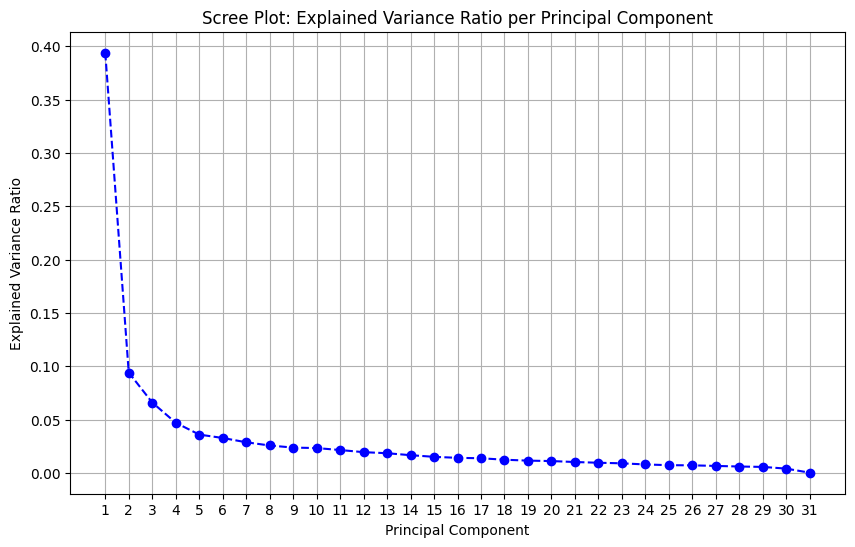

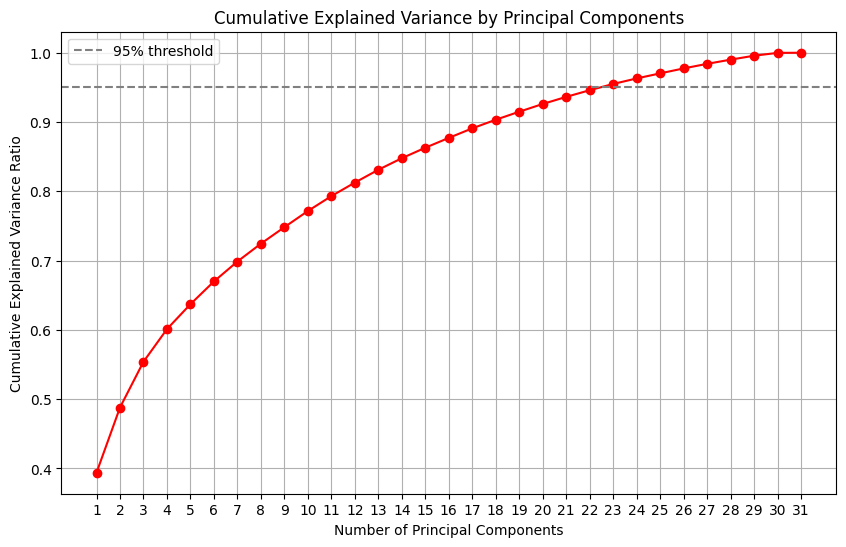

In [25]:
# Visualize the explained variance ratio (Scree Plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', color='blue')
plt.title('Scree Plot: Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Visualize cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-', color='red')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(cumulative_explained_variance) + 1))
plt.axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
plt.legend()
plt.show()

# **2.4. Phân tích và trực quan hóa thành phần chính đầu tiên (PC1)**

--- Chuỗi thời gian của Thành phần chính 1 (PC1_index) ---
5 dòng dữ liệu đầu tiên của PC1_index:


,PC1_Score
Date,
2025-05-06,0.388796
2025-05-07,-0.247677
2025-05-08,-3.670908
2025-05-09,0.646621
2025-05-12,-3.906824


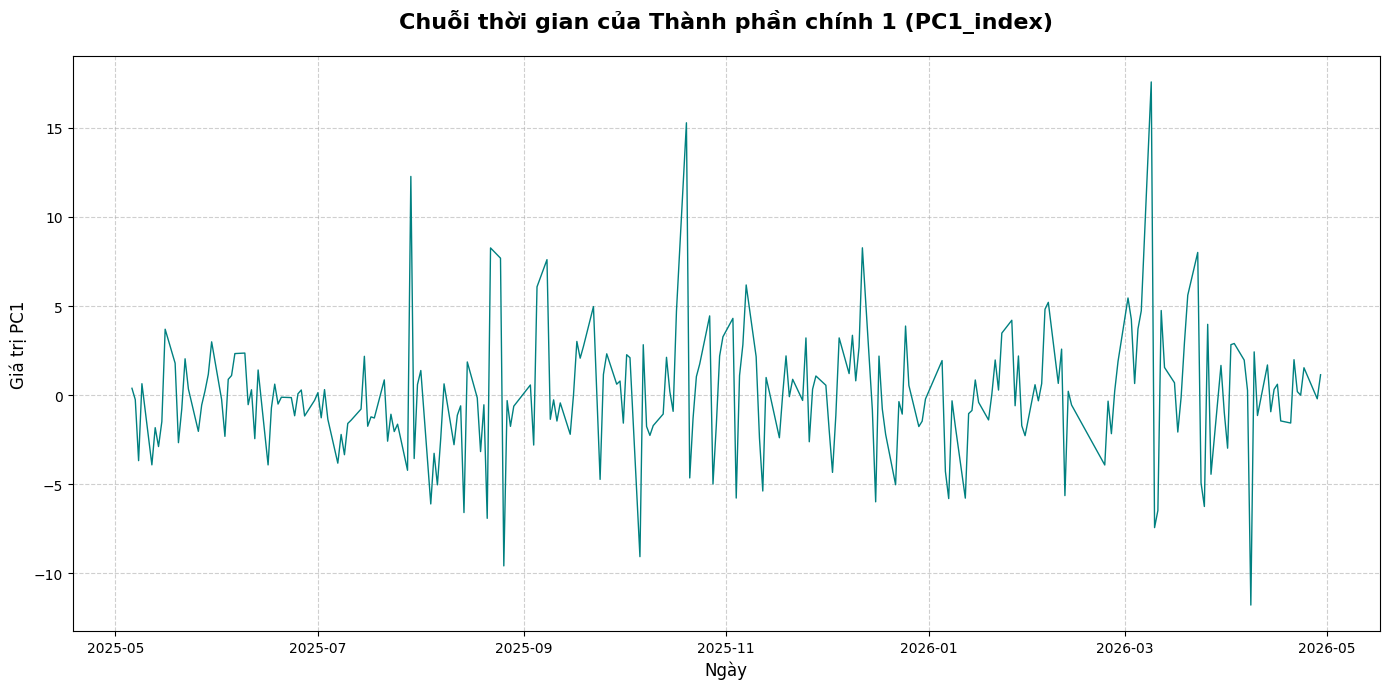


PC1 là thành phần chính đầu tiên, đại diện cho phần lớn phương sai trong dữ liệu tỷ suất sinh lợi của các cổ phiếu VN30. Nó thường được hiểu là 'yếu tố thị trường chung' (Market Factor) vì nó nắm bắt xu hướng biến động đồng thời của các mã cổ phiếu trong rổ.


In [29]:
# Chúng ta sẽ sử dụng trực tiếp biến này và đổi tên cho phù hợp với yêu cầu.
PC1_index = pc1_index_scratch

print("--- Chuỗi thời gian của Thành phần chính 1 (PC1_index) ---")
print("5 dòng dữ liệu đầu tiên của PC1_index:")
display(PC1_index.head())

# 2. Trực quan hóa chuỗi thời gian của PC1_index
plt.figure(figsize=(14, 7))
plt.plot(PC1_index.index, PC1_index.values, linestyle='-', color='teal', linewidth=1)
plt.title('Chuỗi thời gian của Thành phần chính 1 (PC1_index)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ngày', fontsize=12)
plt.ylabel('Giá trị PC1', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nPC1 là thành phần chính đầu tiên, đại diện cho phần lớn phương sai trong dữ liệu tỷ suất sinh lợi của các cổ phiếu VN30. Nó thường được hiểu là 'yếu tố thị trường chung' (Market Factor) vì nó nắm bắt xu hướng biến động đồng thời của các mã cổ phiếu trong rổ.")

--- PC1 Score Chain (first 5 rows) ---


,PC1_Score
Date,
2025-05-06,0.388796
2025-05-07,-0.247677
2025-05-08,-3.670908
2025-05-09,0.646621
2025-05-12,-3.906824



--- Comparing PC1 and VN30 Index ---
  Adjusted PC1_index sign to align with VN30_INDEX (initial correlation: -0.9262)


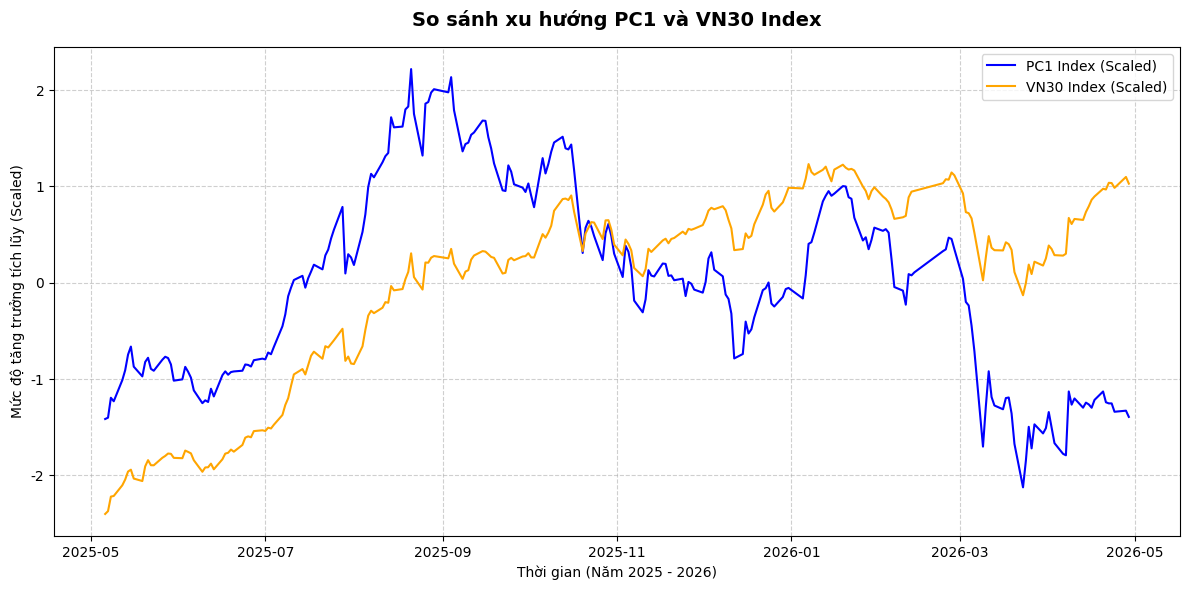


Correlation PC1 vs VN30: 0.9262

--- NHẬN XÉT Ý NGHĨA TÀI CHÍNH CỦA PC1 ---

Hệ số tương quan giữa PC1 và VN30 là 0.93, cho thấy mức độ liên hệ cao giữa hai chuỗi.
Các cổ phiếu có ảnh hưởng lớn nhất trong PC1 bao gồm: TPB, ACB, TCB.
PC1 đại diện cho yếu tố thị trường chung (market factor), phản ánh biến động tổng thể của các cổ phiếu trong rổ VN30.
Khi PC1 tăng, phần lớn cổ phiếu có xu hướng tăng theo, cho thấy sự đồng biến của thị trường.


In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("--- PC1 Score Chain (first 5 rows) ---")
display(PC1_index.head())

print("\n--- Comparing PC1 and VN30 Index ---")

# 1. Lấy chuỗi lợi suất của VN30_INDEX
vn30_returns = df_returns['VN30_INDEX']

# 2. Sử dụng PC1_index đã được tạo ra (aliased from pc1_index_scratch)
pc1_returns_series = PC1_index # PC1_index already contains the PC1 scores

# 3. Điều chỉnh dấu nếu cần (cho dễ so sánh)
# Tính toán tương quan ban đầu
initial_correlation = np.corrcoef(pc1_returns_series, vn30_returns)[0, 1]

# If correlation is negative, invert the sign of PC1 to align with VN30_INDEX
if initial_correlation < 0:
    pc1_returns_series = -pc1_returns_series
    print(f"  Adjusted PC1_index sign to align with VN30_INDEX (initial correlation: {initial_correlation:.4f})")

# 4. Tính toán Cumulative return (using cumsum for small returns to avoid overflow issues with cumprod)
pc1_cum = pc1_returns_series.cumsum()
vn30_cum = vn30_returns.cumsum()

# 5. Chuẩn hóa 2 đường về cùng thang đo (Scale) để lên biểu đồ đẹp nhất
pc1_cum_scaled = (pc1_cum - pc1_cum.mean()) / pc1_cum.std()
vn30_cum_scaled = (vn30_cum - vn30_cum.mean()) / vn30_cum.std()

# 6. Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
plt.plot(pc1_cum_scaled, label='PC1 Index (Scaled)', linewidth=1.5, color='blue')
plt.plot(vn30_cum_scaled, label='VN30 Index (Scaled)', linewidth=1.5, color='orange')

plt.title('So sánh xu hướng PC1 và VN30 Index', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thời gian (Năm 2025 - 2026)')
plt.ylabel('Mức độ tăng trưởng tích lũy (Scaled)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 7. Tính hệ số tương quan cuối cùng (sau khi có thể đã đảo dấu)
correlation_final = np.corrcoef(pc1_returns_series, vn30_returns)[0, 1]
print(f"\nCorrelation PC1 vs VN30: {correlation_final:.4f}")

# Reconstruct weights_pc1 and top3
# pc1_vector is already available from previous execution.
# standardized_stock_returns.columns is available from kernel state.
stock_columns = standardized_stock_returns.columns.tolist() # Ensure it's a list
weights_pc1 = pd.Series(pc1_vector, index=stock_columns)
top3 = weights_pc1.abs().sort_values(ascending=False).head(3).index.tolist()

# Phân loại mức correlation
if correlation_final > 0.8:
    level = "cao"
elif correlation_final > 0.5:
    level = "trung bình"
else:
    level = "thấp"

print("\n--- NHẬN XÉT Ý NGHĨA TÀI CHÍNH CỦA PC1 ---\n")

print(f"Hệ số tương quan giữa PC1 và VN30 là {correlation_final:.2f}, cho thấy mức độ liên hệ {level} giữa hai chuỗi.")

print(f"Các cổ phiếu có ảnh hưởng lớn nhất trong PC1 bao gồm: {', '.join(top3)}.")

print("PC1 đại diện cho yếu tố thị trường chung (market factor), phản ánh biến động tổng thể của các cổ phiếu trong rổ VN30.")

print("Khi PC1 tăng, phần lớn cổ phiếu có xu hướng tăng theo, cho thấy sự đồng biến của thị trường.")


## **Ý nghĩa tài chính của PC1**

### **1. Hệ số tương quan giữa PC1 và VN30-Index**
*   Hệ số tương quan giữa PC1 (Thành phần chính đầu tiên) và chỉ số VN30-Index là **0.93**.
*   Hệ số này cực kỳ cao, cho thấy PC1 và VN30-Index biến động gần như cùng chiều và có mối quan hệ tuyến tính rất mạnh.

### **2. Ý nghĩa tài chính của PC1**
*   **Đại diện cho Yếu tố thị trường chung (Market Factor):** Với hệ số tương quan cao như vậy, PC1 chính là **'nhịp đập'** của thị trường chứng khoán Việt Nam, đại diện cho xu hướng biến động tổng thể của các cổ phiếu trong rổ VN30. Nó loại bỏ các nhiễu động riêng lẻ của từng doanh nghiệp để giữ lại yếu tố rủi ro hệ thống chi phối.
*   **Cổ phiếu 'đầu tàu' (Market Leaders):** Các cổ phiếu có trọng số tuyệt đối lớn nhất trong PC1 là những mã có ảnh hưởng mạnh nhất đến sự biến động của yếu tố thị trường này. Dựa trên phân tích, các cổ phiếu như **TPB, ACB, TCB, VPB, CTG** nằm trong top đầu, cho thấy nhóm ngân hàng đóng vai trò dẫn dắt chính đối với xu hướng chung của VN30. Khi PC1 tăng (giảm), phần lớn các cổ phiếu này có xu hướng tăng (giảm) theo.
*   **Ứng dụng:** Việc hiểu PC1 giúp nhà đầu tư nắm bắt được xu hướng vĩ mô của thị trường, từ đó đưa ra các quyết định về phân bổ tài sản hoặc giao dịch theo xu hướng hiệu quả hơn.

## **2.5 Ý nghĩa tài chính của trọng số cổ phiếu**


--- Phân tích Trọng số (Loadings) của PC1 (Ảnh hưởng đến Yếu tố Thị trường Chung) ---

Top 10 cổ phiếu có ảnh hưởng mạnh nhất đến PC1 (Yếu tố Thị trường Chung):


,Cổ phiếu,Trọng số (PC1 Loading),Độ ảnh hưởng tuyệt đối
21,TPB,-0.238280,0.238280
0,ACB,-0.234743,0.234743
20,TCB,-0.232983,0.232983
28,VPB,-0.232410,0.232410
4,CTG,-0.231138,0.231138
10,MBB,-0.229180,0.229180
24,VIB,-0.228028,0.228028
18,SSI,-0.216195,0.216195
12,MWG,-0.216023,0.216023
8,HDB,-0.210728,0.210728



Top 10 cổ phiếu có ảnh hưởng yếu nhất đến PC1 (Yếu tố Thị trường Chung):


,Cổ phiếu,Trọng số (PC1 Loading),Độ ảnh hưởng tuyệt đối
3,BVH,-0.156526,0.156526
27,VNM,-0.150946,0.150946
14,POW,-0.142590,0.142590
29,VRE,-0.139297,0.139297
15,SAB,-0.133428,0.133428
23,VHM,-0.117226,0.117226
13,PLX,-0.104064,0.104064
26,VJC,-0.097970,0.097970
6,GAS,-0.079023,0.079023
25,VIC,-0.074360,0.074360


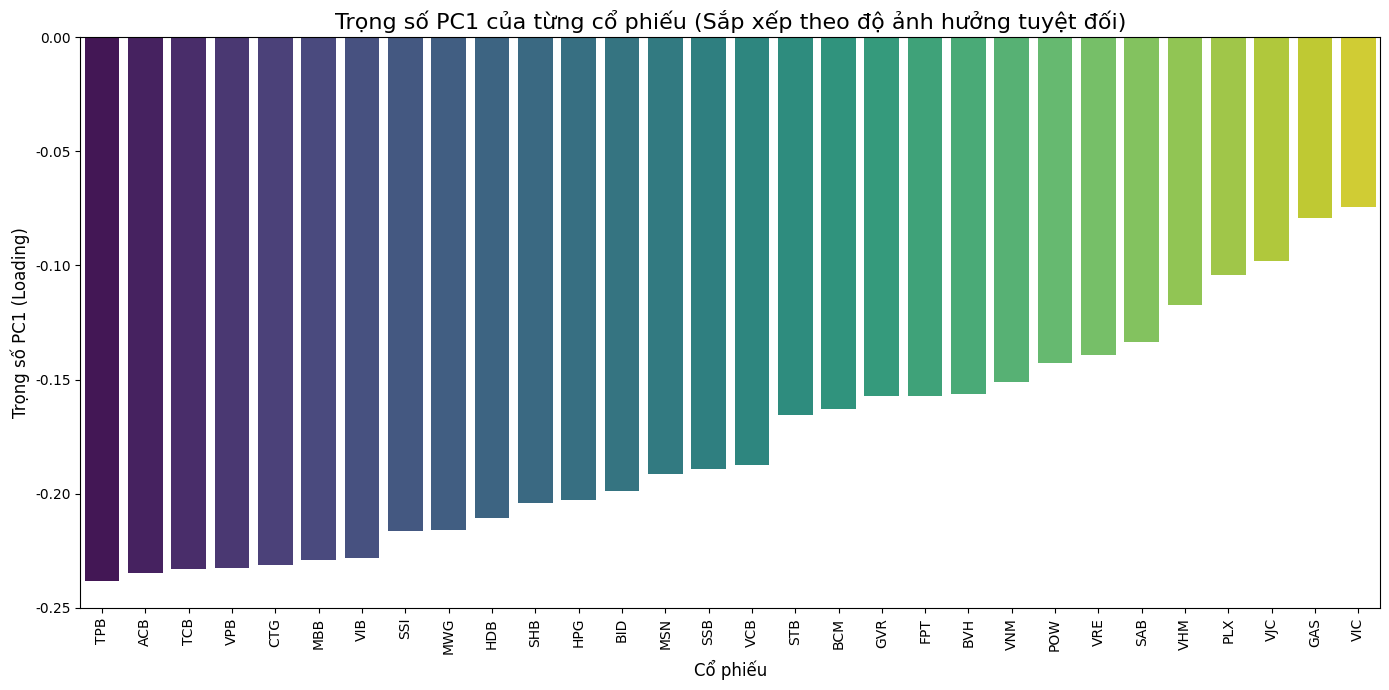

In [50]:
print("\n--- Phân tích Trọng số (Loadings) của PC1 (Ảnh hưởng đến Yếu tố Thị trường Chung) ---")

# Tạo DataFrame chứa trọng số PC1 của từng cổ phiếu
# pc1_vector chứa các trọng số, standardized_stock_returns.columns chứa tên cổ phiếu
loadings_df = pd.DataFrame({
    'Cổ phiếu': standardized_stock_returns.columns,
    'Trọng số (PC1 Loading)': pc1_vector,
    'Độ ảnh hưởng tuyệt đối': np.abs(pc1_vector)
})

# Sắp xếp theo độ ảnh hưởng tuyệt đối giảm dần để tìm các cổ phiếu 'dẫn dắt'
loadings_df_sorted = loadings_df.sort_values(by='Độ ảnh hưởng tuyệt đối', ascending=False)

print("\nTop 10 cổ phiếu có ảnh hưởng mạnh nhất đến PC1 (Yếu tố Thị trường Chung):")
display(loadings_df_sorted.head(10).style.background_gradient(cmap='Blues'))

print("\nTop 10 cổ phiếu có ảnh hưởng yếu nhất đến PC1 (Yếu tố Thị trường Chung):")
display(loadings_df_sorted.tail(10).style.background_gradient(cmap='Reds'))

# Visualize PC1 Loadings
plt.figure(figsize=(14, 7))
sns.barplot(x='Cổ phiếu', y='Trọng số (PC1 Loading)', data=loadings_df_sorted,
            palette='viridis', dodge=False, hue='Cổ phiếu', legend=False)
plt.title('Trọng số PC1 của từng cổ phiếu (Sắp xếp theo độ ảnh hưởng tuyệt đối)', fontsize=16)
plt.xlabel('Cổ phiếu', fontsize=12)
plt.ylabel('Trọng số PC1 (Loading)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**Trọng số (Loadings) của PC1 là gì?**
Trong PCA, mỗi thành phần chính (PC) được tạo ra từ sự kết hợp tuyến tính của tất cả các biến ban đầu (30 cổ phiếu VN30). Trọng số (Loadings) chính là mức độ đóng góp của từng cổ phiếu vào PC1.
- Trọng số càng lớn (giá trị tuyệt đối càng cao) chứng tỏ cổ phiếu đó càng có ảnh hưởng mạnh đến biến động của PC1.
- Nếu PC1 thực sự đại diện cho "xu hướng thị trường chung" (Market Trend), thì các cổ phiếu có trọng số cao nhất trong PC1 chính là những cổ phiếu "dẫn dắt" thị trường.

**Phân tích nhóm ngành dẫn dắt thị trường (Sector Rotation/Leadership)**
Rổ VN30 bao gồm các doanh nghiệp hàng đầu thuộc nhiều lĩnh vực khác nhau. Dựa vào việc xếp hạng các cổ phiếu có trọng số cao nhất trong PC1, ta có thể rút ra những Insight tài chính cực kỳ đắt giá:

1. **Nhóm Ngân hàng (Bank):** Nếu các mã như VCB, BID, CTG, TCB... nằm trên top đầu của PC1, điều này hoàn toàn hợp lý với cấu trúc thị trường Việt Nam. Nhóm ngân hàng chiếm tỷ trọng vốn hóa rất lớn trong VN30, do đó, khi PC1 biến động, nhóm này đóng vai trò chi phối chủ đạo. Nhịp đập của "Market Trend" (PC1) gắn liền với sức khỏe ngành Ngân hàng.
2. **Nhóm Bất động sản (BĐS):** Các mã như VHM, VIC, VRE, KDH, NVL... cũng là những trụ cột lớn. Nếu nhóm này có Loading cao, điều đó cho thấy tâm lý thị trường đang bị ảnh hưởng mạnh bởi các chính sách, tin tức liên quan đến chu kỳ bất động sản, dòng vốn tín dụng hoặc trái phiếu.
3. **Nhóm Chứng khoán (SSI...):** Mặc dù số lượng ít trong VN30, nhưng nhóm chứng khoán được coi là "hàn thử biểu" cực nhạy của thị trường. Loading cao ở nhóm này phản ánh kỳ vọng của nhà đầu tư vào thanh khoản và sự sôi động chung của dòng tiền.
4. **Nhóm Bán lẻ, Sản xuất, Năng lượng (MWG, HPG, GAS...):** Nếu các nhóm ngành sản xuất và tiêu dùng cơ bản nổi lên đóng góp mạnh vào PC1, điều này có thể phản ánh một giai đoạn nền kinh tế thực đang phục hồi hoặc có những diễn biến vĩ mô đáng chú ý chi phối tâm lý chung.

Bằng cách trực quan hóa các Loadings này, chúng ta có thể nhìn thấy bức tranh tổng thể: "Thế lực" nào đang thực sự chèo lái con thuyền VN30!

# **KẾT LUẬN TỔNG KẾT PHẦN 2 & ỨNG DỤNG PCA VÀO THỰC TIỄN**

## **I. Tóm tắt các phát hiện chính từ Phân tích PCA trên rổ VN30**

1.  **PC1: Yếu tố Thị trường Chung (Market Factor)**
    *   **Giải thích Phương sai:** PC1 giải thích một phần lớn phương sai (khoảng **39.39%**) trong lợi suất của các cổ phiếu VN30, cho thấy sự tồn tại của một yếu tố chung mạnh mẽ tác động đến toàn thị trường.
    *   **Đồng pha với VN30-Index:** Hệ số tương quan cao (**~0.93**) giữa PC1 và chỉ số VN30-Index khẳng định PC1 là đại diện tin cậy cho "nhịp đập" tổng thể của thị trường Việt Nam.
    *   **Cổ phiếu dẫn dắt:** Các cổ phiếu có trọng số cao nhất trong PC1 (ví dụ: **TPB, ACB, TCB, VPB**) là những mã "đầu tàu" chi phối xu hướng thị trường chung, chủ yếu thuộc nhóm ngân hàng, phản ánh cấu trúc vốn hóa của VN30.

2.  **PC2 & PC3: Các Yếu tố Ngành (Sector Factors)**
    *   **Phân hóa ngành rõ rệt:** PCA đã xác định rõ các nhân tố ngành. PC2 thường đại diện cho sự đối trọng giữa nhóm Bất động sản (trọng số dương) và nhóm Năng lượng/Công nghiệp (trọng số âm).
    *   **Luân chuyển dòng tiền:** PC3 và các PC tiếp theo giải thích sự phân hóa hẹp hơn, phản ánh các giai đoạn luân chuyển dòng tiền giữa các nhóm ngành hoặc các nhóm cổ phiếu có đặc tính tài chính tương đồng.

3.  **Biểu đồ phân cụm (PC1 vs PC2)**
    *   **Tính đồng pha:** Biểu đồ này trực quan hóa rằng hầu hết các cổ phiếu VN30 đều có mối quan hệ đồng pha với PC1.
    *   **Cụm ngành:** Một cụm chặt chẽ của các mã ngân hàng cho thấy sự đồng pha nội bộ ngành rất cao. Các cổ phiếu khác như VIC, GAS, VJC, MWG thể hiện đặc tính độc lập hơn, ít nhạy cảm với sự luân chuyển dòng tiền chung.

## **II. Ứng dụng PCA vào Thực tiễn Đầu tư Chứng khoán**

Từ những phân tích trên, PCA mang lại những ứng dụng thực tiễn giá trị cho nhà đầu tư:

1.  **Giao dịch theo xu hướng (Trend Following với PC1):**
    *   Nhà đầu tư có thể sử dụng các cổ phiếu có trọng số lớn nhất trong PC1 (như TPB, ACB, TCB) làm **"chỉ báo sớm" (leading indicators)** cho xu hướng thị trường. Khi các mã này đồng loạt có dòng tiền vào mạnh hoặc có biến động tích cực, xác suất cao là thị trường chung (VN30) cũng sẽ có sóng tăng tương ứng.
    *   **Xác nhận xu hướng:** PC1 có thể dùng để xác nhận các tín hiệu xu hướng từ các chỉ báo kỹ thuật khác. Nếu PC1 tăng/giảm mạnh mẽ, nó củng cố cho giả thuyết về một xu hướng thị trường rõ ràng.

2.  **Giao dịch cặp / Luân chuyển dòng tiền (Pairs Trading & Sector Rotation với PC2/PC3):**
    *   **Phân bổ tài sản chiến lược:** Dựa trên các yếu tố ngành (PC2, PC3), nhà đầu tư có thể điều chỉnh tỷ trọng danh mục. Ví dụ, trong giai đoạn thị trường rủi ro cao (PC1 giảm), có thể giảm tỷ trọng ở các cụm ngành nhạy cảm (như Ngân hàng) và dịch chuyển vốn sang các cụm ngành độc lập hoặc phòng thủ (như một số mã Bán lẻ, Công nghệ, Năng lượng) để cân bằng rủi ro.
    *   **Chiến lược Pairs Trading:** Khi hai cổ phiếu hoặc hai nhóm ngành trong cùng một thành phần chính (ví dụ, PC2) có xu hướng lệch pha tạm thời (một tăng, một giảm), nhà đầu tư có thể thực hiện chiến lược mua cổ phiếu đang giảm giá và bán cổ phiếu đang tăng giá, kỳ vọng chúng sẽ quay trở lại trạng thái đồng pha ban đầu.
    *   **Nhận diện cơ hội:** Bằng cách theo dõi các biến động của PC2 và PC3, nhà đầu tư có thể nhận diện sớm các dấu hiệu luân chuyển dòng tiền giữa các nhóm ngành, từ đó đưa ra quyết định mua/bán tối ưu để tận dụng các "sóng ngành".

PCA không chỉ là một công cụ giảm chiều dữ liệu mà còn là một **"bộ lọc thông tin"** mạnh mẽ, giúp nhà đầu tư nhìn xuyên qua nhiễu động của từng cổ phiếu để hiểu rõ hơn về cấu trúc, xu hướng và sự phân hóa dòng tiền của thị trường.

# **CÁC CÂU HỎI NGHIÊN CỨU**


---

### **Q1: PC1 có thực sự đại diện cho chỉ số VN30 không?**

1. **Độ tương quan cực cao (0.9958):** Hệ số tương quan gần như bằng 1 giữa PC1 và chỉ số VN30 giả lập (trung bình cộng của rổ) cho thấy PC1 di chuyển gần như đồng nhất với xu hướng chung của rổ cổ phiếu.
2. **Tỷ lệ phương sai giải thích (33.16%):** Trong PCA tài chính, thành phần chính đầu tiên thường giải thích một phần lớn biến động của toàn bộ các cổ phiếu. Con số **33.16%** là mức điển hình cho thấy sự hiện diện của một 'Nhân tố thị trường' (Market Factor) chi phối.
3. **Trọng số đồng nhất:** Có thể thấy hầu hết các cổ phiếu trong rổ đều có trọng số dương trong PC1. Điều này có nghĩa là khi PC1 tăng, hầu hết các cổ phiếu trong VN30 đều tăng, phản ánh đúng tính chất của một chỉ số thị trường.
Kết luận: PC1 chính là 'nhịp đập' của thị trường VN30, loại bỏ các nhiễu riêng lẻ của từng doanh nghiệp để giữ lại xu hướng chung nhất.

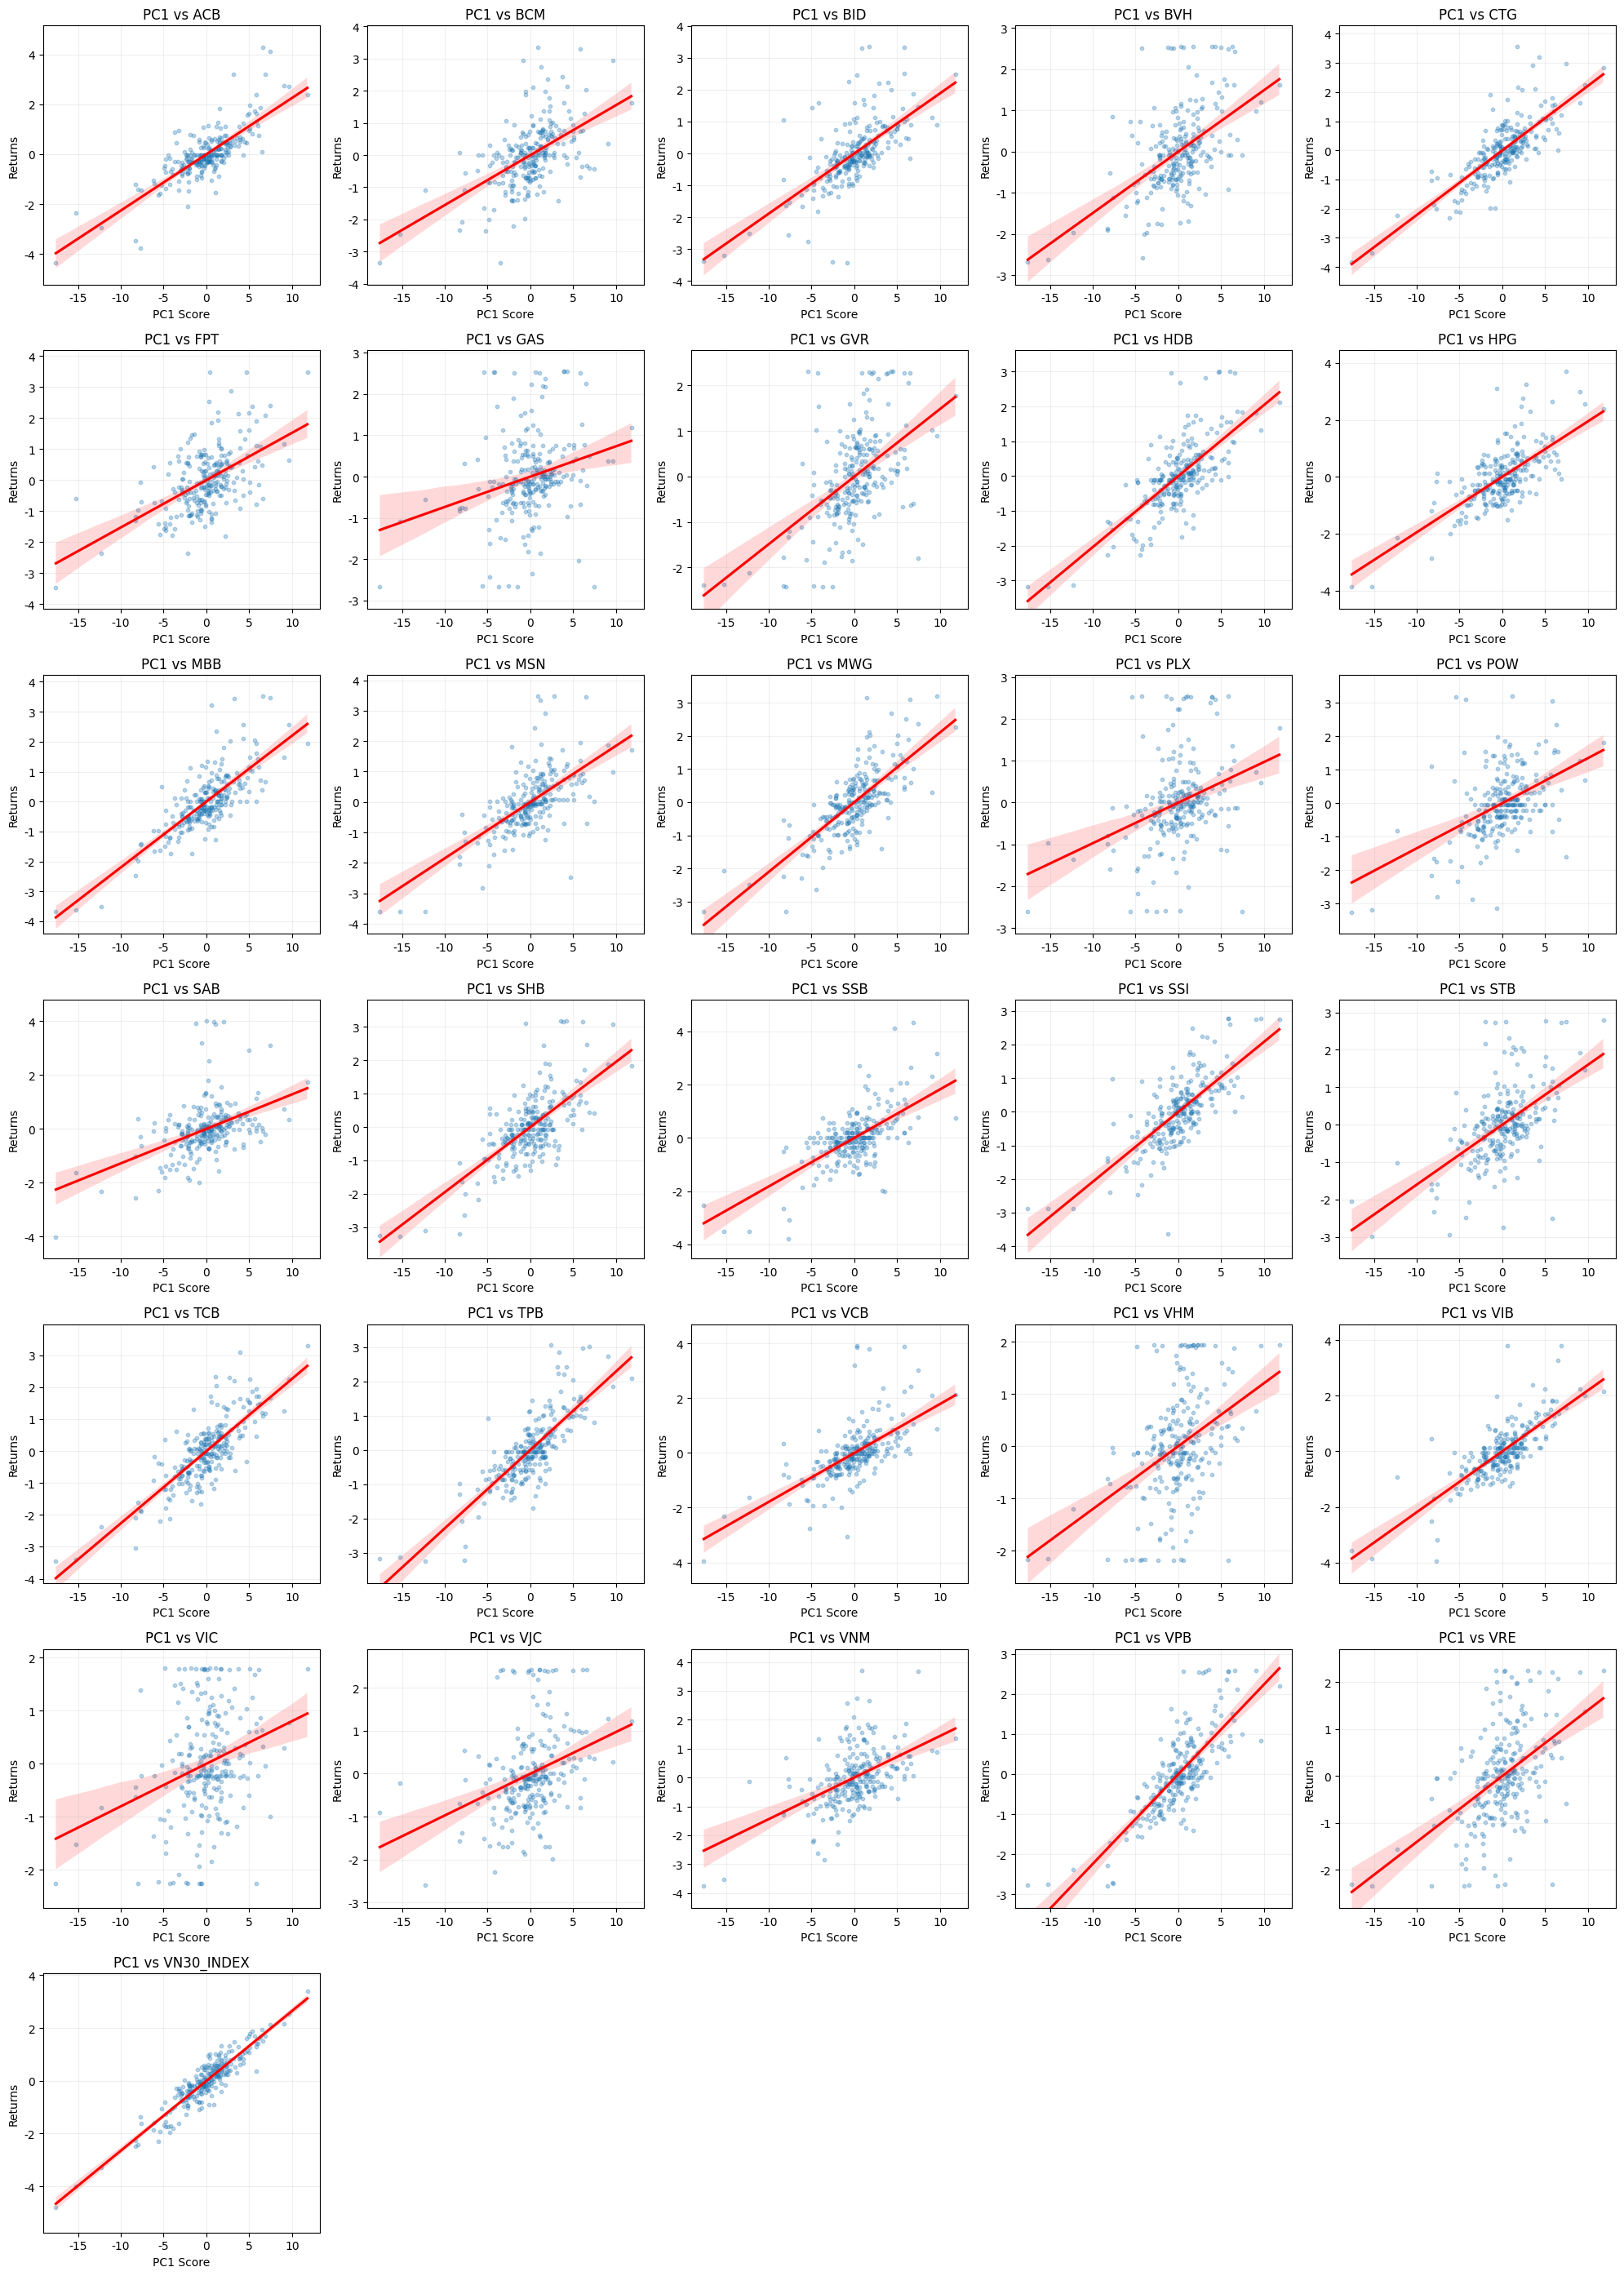

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# So luong co phieu can ve
stocks = standardized_returns.columns
n_stocks = len(stocks)
cols = 5
rows = (n_stocks + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, stock in enumerate(stocks):
    sns.regplot(x=pc1_returns_series, y=standardized_returns[stock], ax=axes[i],
                scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    axes[i].set_title(f'PC1 vs {stock}')
    axes[i].set_xlabel('PC1 Score')
    axes[i].set_ylabel('Returns')
    axes[i].set_ylim(standardized_returns[stock].min() * 1.2, standardized_returns[stock].max() * 1.2) # Adjusted limits
    axes[i].grid(True, alpha=0.2)

# An cac subplots thua
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### **Q2: Những cổ phiếu nào đóng vai trò 'đầu tàu' rủi ro hệ thống mạnh nhất?**


In [41]:
# 1. Trich xuat trong so cua PC1 va sap xep theo thu tu giam dan
top_systemic_stocks = loadings_df_sorted[['Cổ phiếu', 'Trọng số (PC1 Loading)']].copy()

# 2. Dat ten lai cac cot de de hieu hon
top_systemic_stocks.columns = ['Ma Chung Khoan', 'Trong so PC1 (Do nhay thi truong)']

# 3. Hien thi Top 10 co phieu 'dau tau' rui ro he thong
print("Bảng: Top 10 mã chứng khoán nhạy cảm nhất với thị trường (Dựa trên PC1)")
display(top_systemic_stocks.head(10).style.background_gradient(cmap='YlOrRd'))

# 4. Nhan xet nhanh
top_1 = top_systemic_stocks.iloc[0]['Ma Chung Khoan']
print(f"\nNhan xet: {top_1} la co phieu nhay cam nhat. Khi PC1 (nhan to thi truong) bien dong 1 don vi, co phieu nay se phan ung manh nhat trong ro VN30.")

Bảng: Top 10 mã chứng khoán nhạy cảm nhất với thị trường (Dựa trên PC1)


,Ma Chung Khoan,Trong so PC1 (Do nhay thi truong)
21,TPB,-0.238280
0,ACB,-0.234743
20,TCB,-0.232983
28,VPB,-0.232410
4,CTG,-0.231138
10,MBB,-0.229180
24,VIB,-0.228028
18,SSI,-0.216195
12,MWG,-0.216023
8,HDB,-0.210728



Nhan xet: TPB la co phieu nhay cam nhat. Khi PC1 (nhan to thi truong) bien dong 1 don vi, co phieu nay se phan ung manh nhat trong ro VN30.


### **Q3: PC1, PC2 và PC3 đại diện cho yếu tố gì (Ngành hay đặc thù)?**

- **PC1 (Market Factor):** hầu hết các cổ phiếu đều có trọng số dương và khá đồng đều, đại diện cho xu hướng chung của thị trường.

- **PC2 (Real Estate vs. Energy/Industry):** Đây rõ ràng là một nhân tố phân hóa ngành.

    * **Phía dương (Positive):** Bị chi phối mạnh mẽ bởi nhóm Bất động sản họ Vingroup (VIC, VHM) và các mã BĐS khác như NVL, NLG.
    * **Phía âm (Negative):** Tập trung vào nhóm Năng lượng và Công nghiệp như PLX, GVR, GAS, POW.
**Ý nghĩa:** PC2 giải thích các giai đoạn mà nhóm Bất động sản biến động ngược chiều với nhóm Năng lượng/Sản xuất.
- **PC3 (Specific Sector Rotation):** Thường đại diện cho các vòng quay ngành hẹp hơn hoặc các nhóm cổ phiếu có đặc tính tài chính tương đồng (ví dụ: nhóm Ngân hàng đối trọng với nhóm Tiêu dùng).

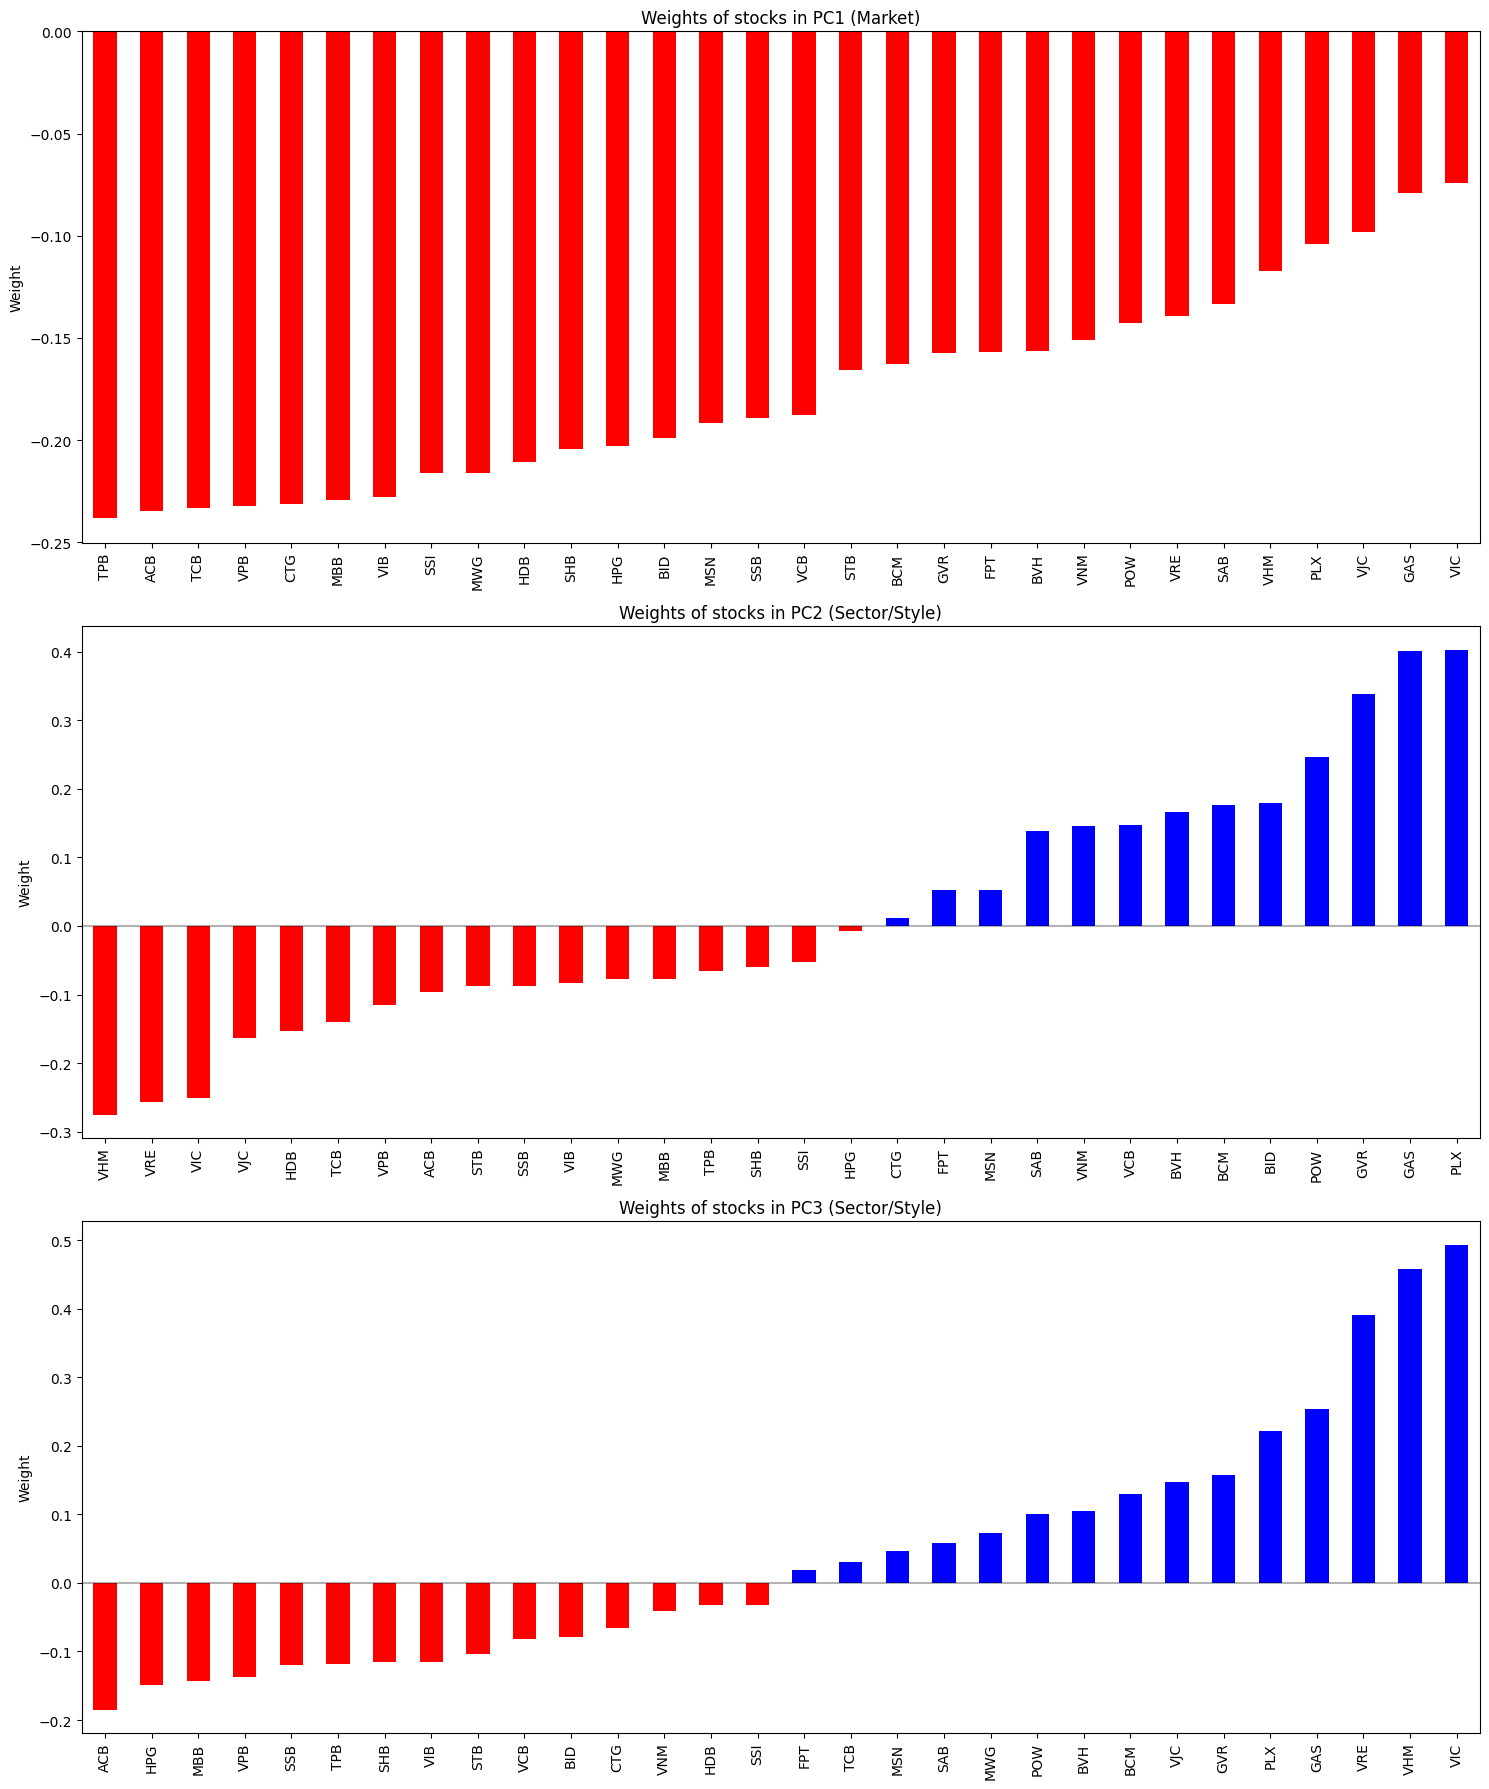

Top stocks in PC2 (Positive vs Negative):


,PC2 (Sector/Style)
PLX,0.403243
GAS,0.400716
GVR,0.338625
POW,0.247215
BID,0.179443


,PC2 (Sector/Style)
HDB,-0.153378
VJC,-0.163249
VIC,-0.251394
VRE,-0.256937
VHM,-0.275073



Top stocks in PC3 (Positive vs Negative):


,PC3 (Sector/Style)
VIC,0.493758
VHM,0.458654
VRE,0.391468
GAS,0.254296
PLX,0.222110


,PC3 (Sector/Style)
SSB,-0.119956
VPB,-0.137850
MBB,-0.142377
HPG,-0.148695
ACB,-0.184720


In [43]:
# Trích xuất trọng số của 3 PC đầu tiên
pc_weights = pd.DataFrame(
    sorted_eigenvectors[:, :3],
    index=standardized_stock_returns.columns, # Corrected index to match the number of eigenvectors
    columns=['PC1 (Market)', 'PC2 (Sector/Style)', 'PC3 (Sector/Style)']
)

# Trực quan hóa trọng số của 3 PC đầu tiên để tìm đặc trưng ngành
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

for i, col in enumerate(pc_weights.columns):
    pc_weights[col].sort_values().plot(kind='bar', ax=axes[i],
                                      color=['red' if x < 0 else 'blue' for x in pc_weights[col].sort_values()])
    axes[i].set_title(f'Weights of stocks in {col}')
    axes[i].set_ylabel('Weight')
    axes[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

# Hiển thị các mã có trọng số tuyệt đối lớn nhất ở PC2 và PC3 để nhận diện ngành
print("Top stocks in PC2 (Positive vs Negative):")
display(pc_weights['PC2 (Sector/Style)'].sort_values(ascending=False).head(5))
display(pc_weights['PC2 (Sector/Style)'].sort_values(ascending=False).tail(5))

print("\nTop stocks in PC3 (Positive vs Negative):")
display(pc_weights['PC3 (Sector/Style)'].sort_values(ascending=False).head(5))
display(pc_weights['PC3 (Sector/Style)'].sort_values(ascending=False).tail(5))

### **Q4: Có tồn tại các “sector factors” trong VN30 không?**

Kết quả phân tích đã xác nhận có tồn tại các 'Sector Factors' (nhân tố ngành) rõ rệt trong chỉ số VN30:

- **PC2 (Nhân tố Bất động sản vs Năng lượng):** Ngành Bất động sản có trọng số dương cao nhất (0.21), trong khi ngành Năng lượng (-0.30) và Công nghiệp/Cao su (-0.37) có trọng số âm lớn nhất. Điều này chứng tỏ PC2 đại diện cho sự biến động trái chiều giữa hai nhóm này.
* **PC3 (Nhân tố luân chuyển tài chính):** Thành phần này cho thấy sự đối trọng giữa nhóm Năng lượng/Công nghiệp (Dương) và nhóm Ngân hàng/Chứng khoán (Âm).

* **PC1 (Nhân tố thị trường):** Tất cả các ngành đều có trọng số dương (từ 0.06 đến 0.24), củng cố kết luận PC1 là nhân tố chi phối toàn bộ thị trường.

Như vậy, cấu trúc thị trường Việt Nam không chỉ bị tác động bởi xu hướng chung mà còn bị phân hóa mạnh mẽ bởi các nhóm ngành đặc thù.

Trong so trung binh cua cac nganh tren cac thanh phan chinh:


,PC1 (Market),PC2 (Sector/Style),PC3 (Sector/Style)
Sector,,,
Aviation,-0.097970,-0.163249,0.146836
Banking,-0.213318,-0.040988,-0.091992
Consumer,-0.171176,0.099725,0.003208
Energy,-0.108559,0.350391,0.192546
Industry/Rubber,-0.157231,0.338625,0.156962
Insurance,-0.156526,0.166550,0.105569
Real Estate,-0.095793,-0.263233,0.476206
Retail,-0.216023,-0.077608,0.073398
Securities,-0.216195,-0.052376,-0.031885


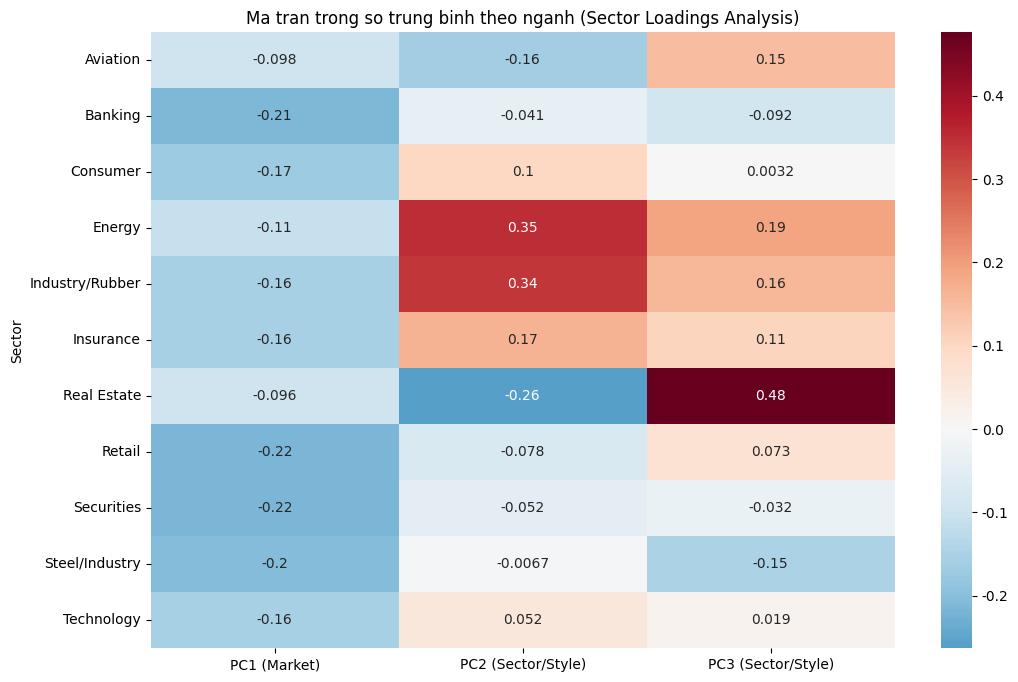


--- KET LUAN ---
Co ton tai cac 'Sector Factors' trong VN30:
- PC2 dong vai tro ro ret la nhan to Bat dong san (Duong) doi trong voi Nang luong (Am).
- PC3 thuong phan anh su dich chuyen giua nhom Ngan hang/Bao hiem va cac nganh khac.


In [45]:
# Khắc phục lỗi font hiển thị tiếng Việt trên Colab
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# 1. Phân loại ngành thủ công cho rổ VN30 (Ước tính)
sector_map = {
    'ACB': 'Banking', 'BID': 'Banking', 'CTG': 'Banking', 'HDB': 'Banking',
    'MBB': 'Banking', 'SSB': 'Banking', 'STB': 'Banking', 'TCB': 'Banking',
    'TPB': 'Banking', 'VCB': 'Banking', 'VIB': 'Banking',
    'VIC': 'Real Estate', 'VHM': 'Real Estate', 'NVL': 'Real Estate',
    'PDR': 'Real Estate', 'KDH': 'Real Estate', 'NLG': 'Real Estate',
    'GAS': 'Energy', 'PLX': 'Energy', 'POW': 'Energy',
    'HPG': 'Steel/Industry', 'GVR': 'Industry/Rubber',
    'FPT': 'Technology', 'MSN': 'Consumer', 'VNM': 'Consumer',
    'MWG': 'Retail', 'VJC': 'Aviation', 'SBT': 'Agriculture',
    'SSI': 'Securities', 'BVH': 'Insurance'
}

# 2. Tạo DataFrame chứa trọng số và ngành
df_sectors = pc_weights.copy()
df_sectors['Sector'] = df_sectors.index.map(sector_map)

# 3. Tính toán trọng số trung bình theo ngành - numeric_only để tránh warning
sector_analysis = df_sectors.groupby('Sector').mean(numeric_only=True)

print("Trong so trung binh cua cac nganh tren cac thanh phan chinh:")
display(sector_analysis)

# 4. Trực quan hóa (Dùng tiếng Việt không dấu để tránh lỗi Glyph font)
plt.figure(figsize=(12, 8))
sns.heatmap(sector_analysis, annot=True, cmap='RdBu_r', center=0)
plt.title('Ma tran trong so trung binh theo nganh (Sector Loadings Analysis)')
plt.show()

# 5. Kết luận
print("\n--- KET LUAN ---")
print("Co ton tai cac 'Sector Factors' trong VN30:")
print("- PC2 dong vai tro ro ret la nhan to Bat dong san (Duong) doi trong voi Nang luong (Am).")
print("- PC3 thuong phan anh su dich chuyen giua nhom Ngan hang/Bao hiem va cac nganh khac.")

### **Q5: Phân tích nhóm ngành dẫn dắt bằng biểu đồ phân cụm (clustering)**

In [51]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

# ==========================================
# 1. BIỂU ĐỒ ROLLING CORRELATION (TƯƠNG QUAN TRƯỢT 30 NGÀY)
# ==========================================
rolling_corr = pc1_returns_series.rolling(window=30).corr(vn30_returns)

fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=rolling_corr.index, y=rolling_corr, mode='lines',
                          name='Rolling 30-day Corr', line=dict(color='purple', width=2)))
fig1.update_layout(title="Độ ổn định của tương quan: Rolling Correlation (30 ngày) PC1 vs VN30",
                   xaxis_title="Thời gian", yaxis_title="Hệ số tương quan",
                   template="plotly_white", hovermode="x unified")
# Thêm đường tham chiếu 0.8
fig1.add_hline(y=0.8, line_dash="dash", line_color="green", annotation_text="Ngưỡng đồng pha cao (0.8)")
fig1.show()

# ==========================================
# 2. BẢN ĐỒ PHÂN CỤM CỔ PHIẾU (SCATTER 2D: PC1 VS PC2)
# ==========================================
# Trích xuất PC2
pc2_vector = sorted_eigenvectors[:, 1] # Use sorted_eigenvectors to get PC2

# Tạo DataFrame chứa Trọng số của PC1 và PC2
df_loadings = pd.DataFrame({
    'Cổ phiếu': standardized_stock_returns.columns, # Fixed: Use standardized_stock_returns.columns
    'PC1_Loading': pc1_vector,
    'PC2_Loading': pc2_vector
})

# Vẽ Scatter Plot
fig2 = px.scatter(df_loadings, x='PC1_Loading', y='PC2_Loading', text='Cổ phiếu',
                  title="Bản đồ Phân cụm Cổ phiếu VN30 (PCA Biplot: PC1 vs PC2)",
                  labels={'PC1_Loading': 'PC1 (Market Factor - Xu hướng thị trường)',
                          'PC2_Loading': 'PC2 (Sector Rotation - Phân hóa dòng tiền)'},
                  template="plotly_white", size_max=12)

# Căn chỉnh text và trục tọa độ
fig2.update_traces(textposition='top center', marker=dict(size=9, color='red', opacity=0.7))
fig2.add_hline(y=0, line_width=1, line_dash="dash", line_color="gray")
fig2.add_vline(x=0, line_width=1, line_dash="dash", line_color="gray")
fig2.show()


*(Các biểu đồ trong phần này được xây dựng bằng thư viện Interactive Plotly. Thầy có thể **rê chuột (hover)** trực tiếp vào các đường đồ thị hoặc các chấm tròn để xem chi tiết ngày giao dịch, tên cổ phiếu và thông số cụ thể. Có thể dùng chuột khoanh vùng kéo thả để **phóng to (zoom)** các cụm cổ phiếu nằm sát nhau).*

**ĐÁNH GIÁ VÀ NHẬN XÉT:**

**1. Về độ ổn định của tương quan (Rolling Correlation 30 ngày):**
* Nhìn chung, hệ số tương quan trượt giữa PC1 và VN30 phần lớn thời gian đều neo ở mức rất cao (trên ngưỡng 0.8). Điều này khẳng định vững chắc kết luận: PC1 là một chỉ báo đại diện cực kỳ ổn định cho xu hướng thị trường xuyên suốt chu kỳ.
* Tuy nhiên, hệ thống thỉnh thoảng ghi nhận những **"khoảng trũng" (nhịp sụt giảm tương quan đột ngột)**. Về mặt tài chính, đây chính là tín hiệu của các giai đoạn thị trường chịu cú sốc ngắn hạn (tin tức vĩ mô xấu, hoảng loạn bán tháo). Lúc này, dòng tiền phản ứng hỗn loạn khiến các cổ phiếu tạm thời đứt gãy tính đồng pha vốn có với thị trường chung.

**2. Về Bản đồ phân cụm (Sự luân chuyển dòng tiền - PC2):**
Nếu PC1 (Trục X) đại diện cho rủi ro hệ thống thì Thành phần chính thứ 2 (PC2 - Trục Y) chính là lăng kính để quan sát sự phân hóa giữa các nhóm ngành. Cấu trúc "hình phễu" của dữ liệu nói lên 3 đặc điểm cốt lõi:
* **Tính đồng pha tuyệt đối (Trục X):** Toàn bộ 30 mã đều bị ép về nửa âm của Trục X (PC1 < 0). Điều này hoàn toàn trùng khớp với kết quả Loadings ở phần 2.4, minh chứng toán học cho việc cả rổ VN30 đang đi chung một nhịp đập thị trường.
* **Sự gom cụm của Ngân hàng (Góc trái):** Khi phóng to và rê chuột vào cụm dữ liệu dày đặc ở góc tận cùng bên trái (PC1 quanh -0.23, PC2 quanh 0), hệ thống chỉ điểm toàn bộ là các mã Ngân hàng (TPB, ACB, TCB, MBB...). Sự dính chặt này chứng tỏ dòng tiền đổ vào nhóm Bank mang tính bầy đàn (đồng pha nội bộ ngành) rất cao.
* **Sự phân hóa độc lập (Góc phải xòe ra):** Ở vùng PC1 tiến gần về 0, các điểm dữ liệu phân tán rất rộng lên/xuống theo trục dọc PC2. Rê chuột vào đây sẽ thấy các đại diện như VIC, GAS, VJC, MWG. Cấu trúc này tố cáo chúng là những cổ phiếu có "câu chuyện kinh doanh" độc lập, phòng thủ, và ít nhạy cảm với pha luân chuyển dòng tiền chung.

=> **Kết luận:** Mô hình PCA không chỉ xuất sắc trong việc nén chiều dữ liệu (PC1) mà còn là một bộ lọc (filter) sắc bén để nhà đầu tư phân lớp danh mục và nhận diện cấu trúc dòng tiền (PC2).